# Last Run

c:\Users\My Pc\Desktop\Jisan\journal\review reponse applied soft computing\Review Progress file\R1C8\Rice-Leaf-Disease-Classification-using-Response-Based-Knowledge-Distillation\tf215_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(



Base seed from system time: 96400
Randomly selected seeds: [6789, 3721, 1918, 8259, 7854]

Loading test set...
Found 595 images belonging to 4 classes.
Loading validation set...
Found 592 images belonging to 4 classes.

Loading teacher model...


Evaluating teacher model on test set...

Teacher Test Accuracy: 99.16%
Teacher Test Loss: 0.0710

Loading student model architecture...
Evaluating original student model on test set...
Original Student Test Accuracy: 77.82%
Original Student Test Loss: 0.5833

STABILITY ANALYSIS - Temperature T=10
Running experiments with 5 different random seeds


EXPERIMENT 1/5 - Seed: 6789
Creating fresh training set...
Found 4745 images belonging to 4 classes.
Creating fresh student model...
Initializing distiller...

✓ Distiller compiled with temperature: 10
Training with seed 6789...
Epoch 1/30

149/149 [==============================] - 59s 388ms/step - accuracy: 0.4032 - mse: 0.1658 - rmse: 0.4071 - loss: 0.1883 - student_loss: 1.2186 - distillation_lo

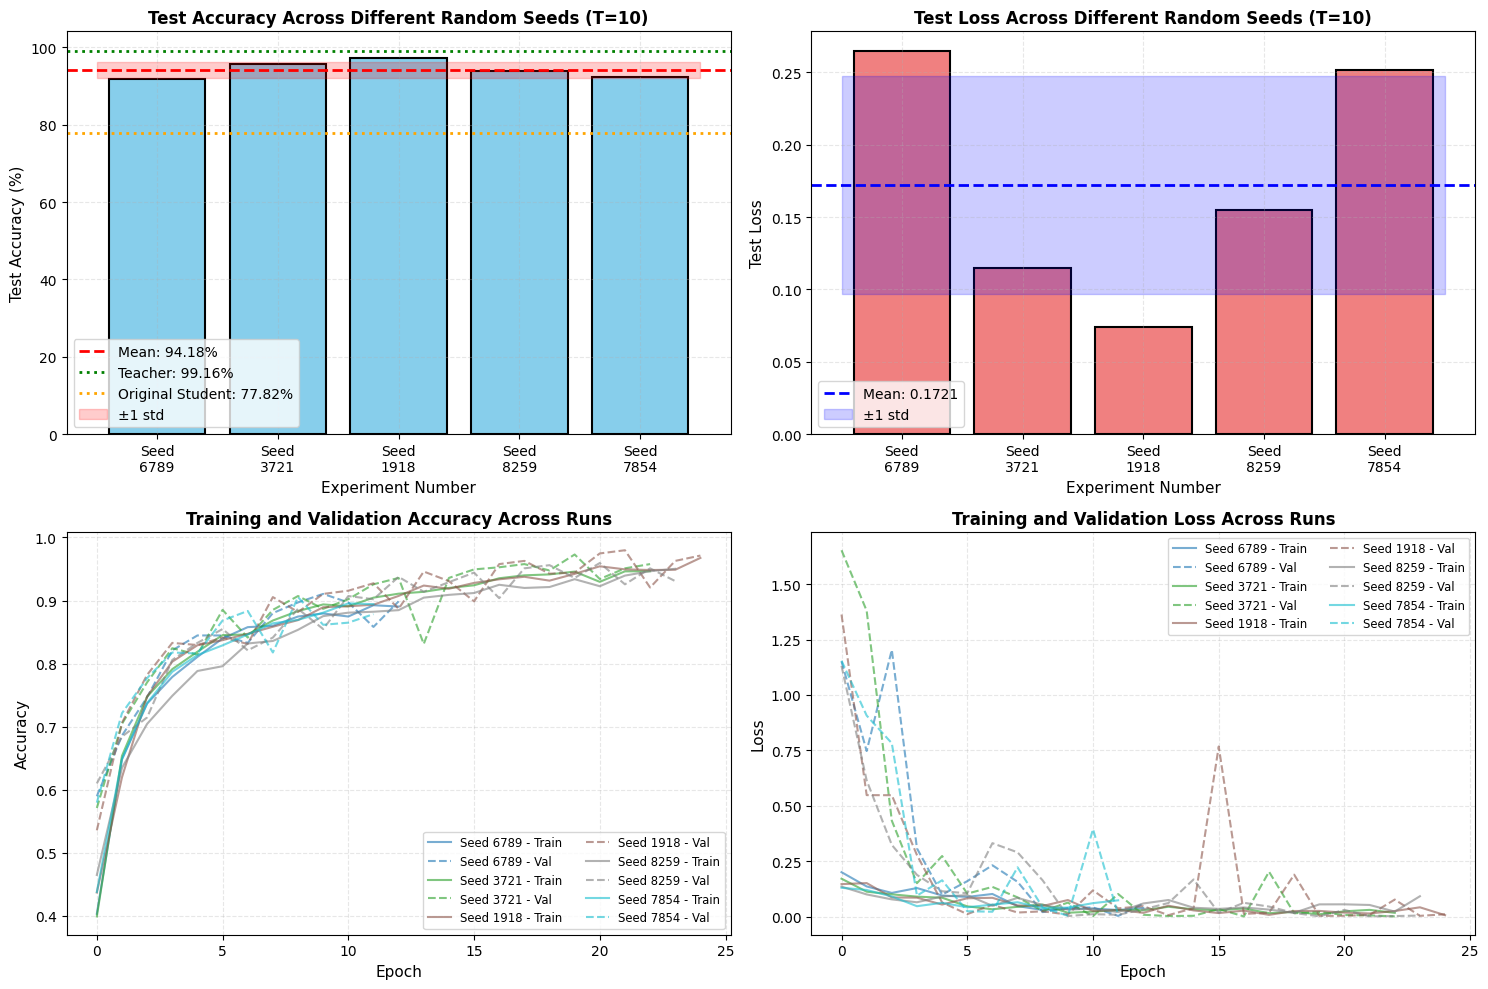


EXPERIMENT COMPLETE
Temperature T=10 stability analysis across 5 random seeds.
Mean Test Accuracy: 94.18% ± 2.101%
Improvement: +16.37% over original student
95% CI for Accuracy: [91.58%, 96.79%]

SELECTING BEST MODEL
Best Model from Seed: 1918
Best Test Accuracy: 97.31%
Best Test Loss: 0.0737

✓ Best model saved to: saved_models/best_distilled_student_T10_seed1918.h5
✓ Model info saved to: saved_models/best_model_info_T10.json

GENERATING DETAILED EVALUATION METRICS

Generating predictions on test set...


c:\Users\My Pc\Desktop\Jisan\journal\review reponse applied soft computing\Review Progress file\R1C8\Rice-Leaf-Disease-Classification-using-Response-Based-Knowledge-Distillation\tf215_env\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✓ Generated predictions for 595 test samples
✓ Number of classes: 4
✓ Class names: ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']

CONFUSION MATRIX

Raw Confusion Matrix:
[[157   2   0   0]
 [  4 135   5   0]
 [  4   0 156   0]
 [  1   0   0 131]]

✓ Confusion matrix saved to: saved_models/confusion_matrix_T10.png


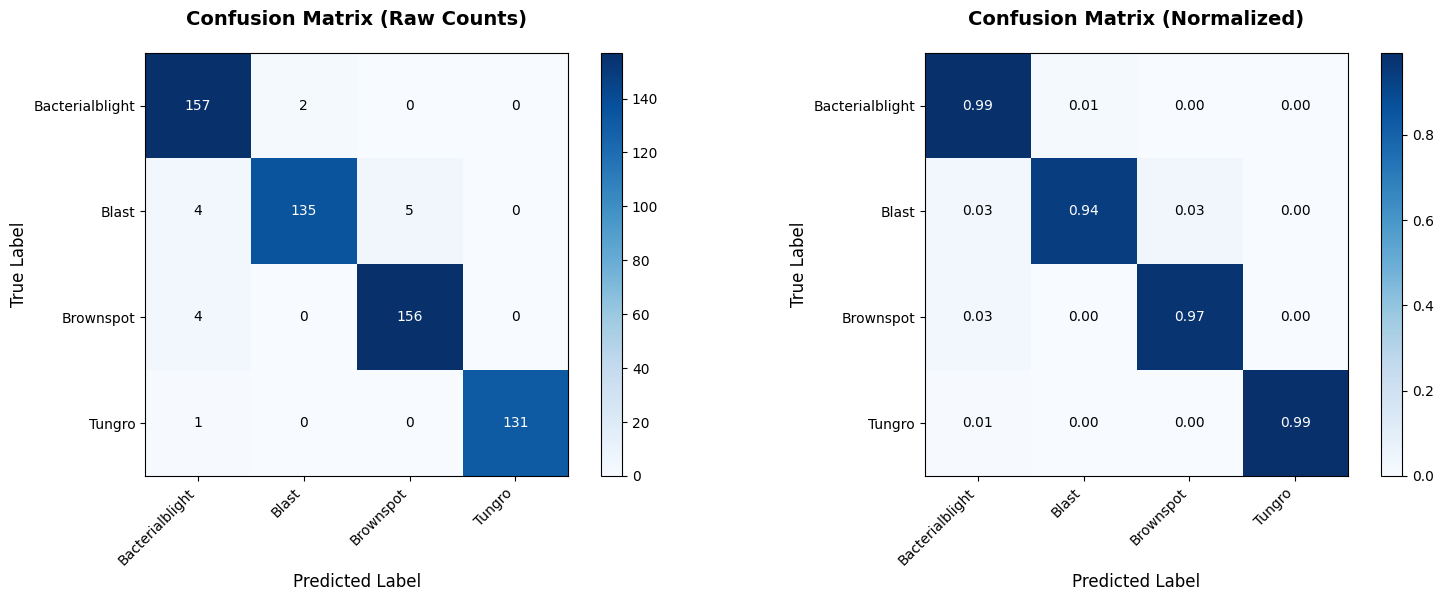


CLASSIFICATION REPORT

                 precision    recall  f1-score   support

Bacterialblight     0.9458    0.9874    0.9662       159
          Blast     0.9854    0.9375    0.9609       144
      Brownspot     0.9689    0.9750    0.9720       160
         Tungro     1.0000    0.9924    0.9962       132

       accuracy                         0.9731       595
      macro avg     0.9750    0.9731    0.9738       595
   weighted avg     0.9736    0.9731    0.9731       595

✓ Classification report saved to: saved_models/classification_report_T10.txt
✓ Classification report (JSON) saved to: saved_models/classification_report_T10.json

GENERATING PER-CLASS PERFORMANCE CHARTS



C:\Users\My Pc\AppData\Local\Temp\ipykernel_9068\4084036634.py:757: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(class_names, rotation=45, ha='right')
C:\Users\My Pc\AppData\Local\Temp\ipykernel_9068\4084036634.py:773: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(class_names, rotation=45, ha='right')
C:\Users\My Pc\AppData\Local\Temp\ipykernel_9068\4084036634.py:787: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(class_names, rotation=45, ha='right')


✓ Per-class performance chart saved to: saved_models/per_class_performance_T10.png


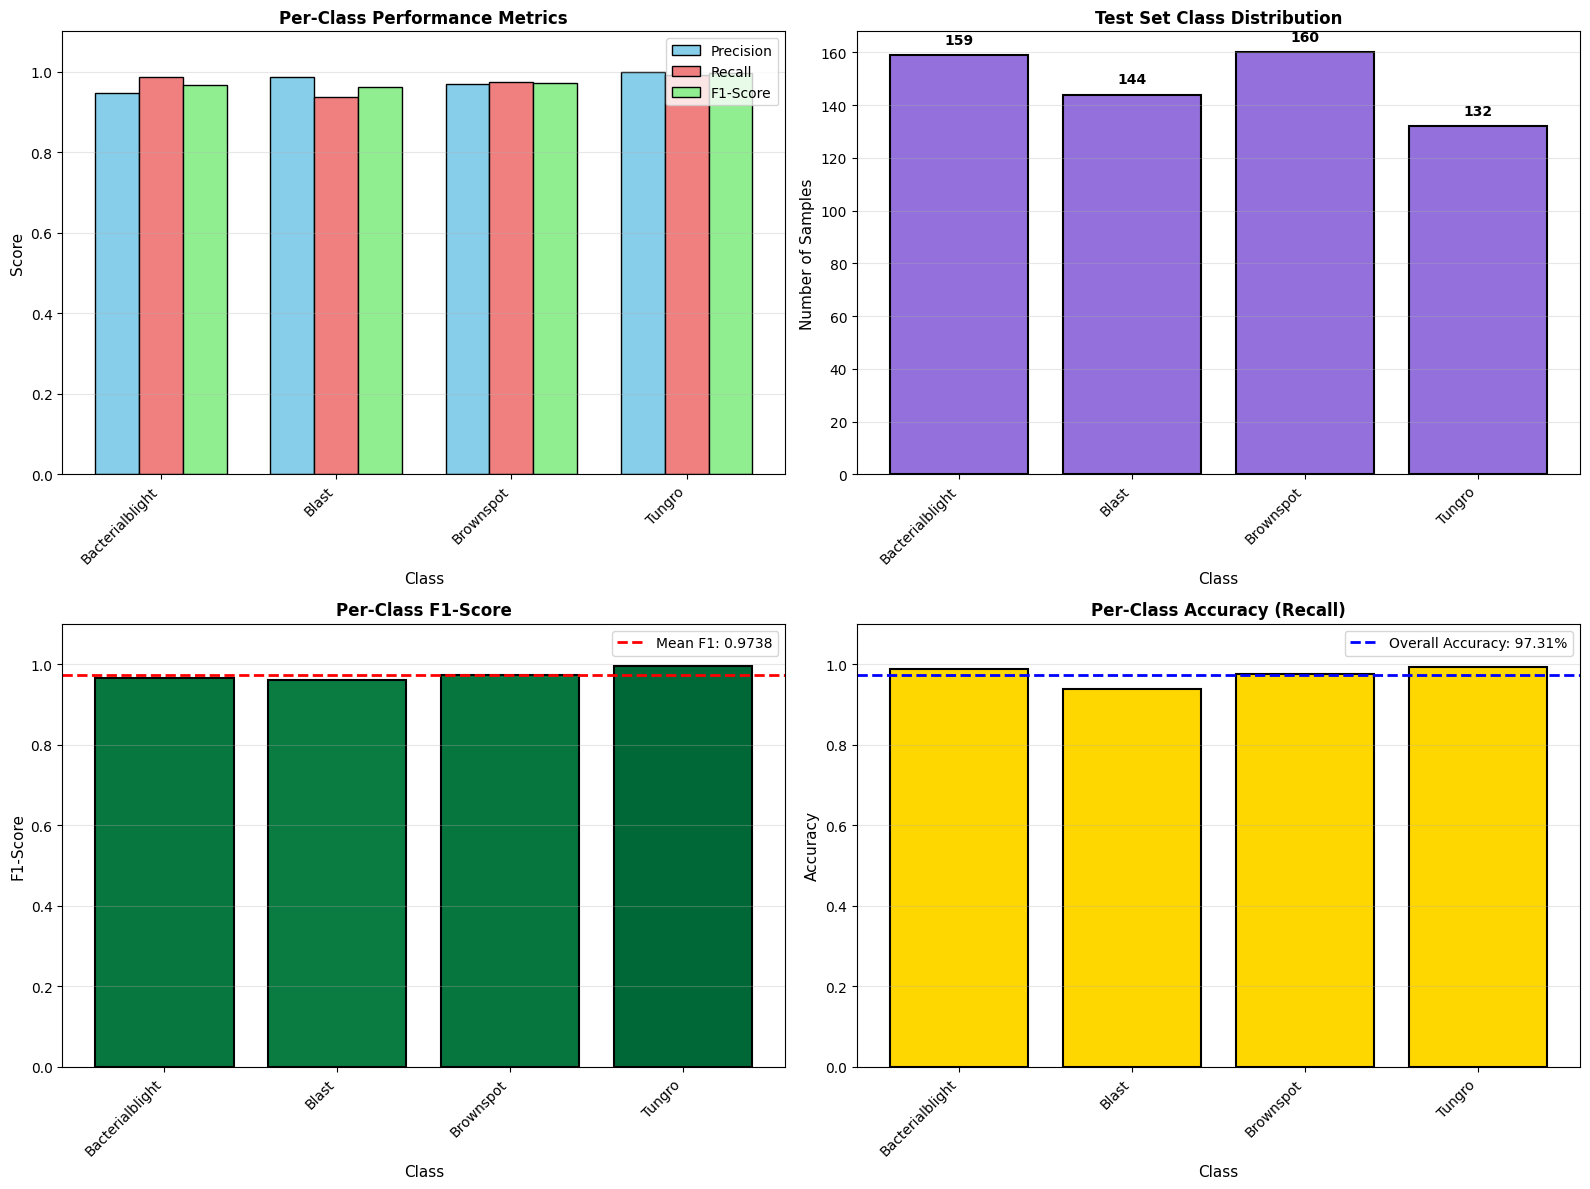


FINAL SUMMARY

+------------------------------------------+----------------------+
| Metric                                   | Value                |
+==========================================+======================+
| ──────────────────────────────────────── | ──────────────────── |
+------------------------------------------+----------------------+
| Temperature                              | 10                   |
+------------------------------------------+----------------------+
| Best Seed                                | 1918                 |
+------------------------------------------+----------------------+
| ──────────────────────────────────────── | ──────────────────── |
+------------------------------------------+----------------------+
| Teacher Accuracy                         | 99.16%               |
+------------------------------------------+----------------------+
| Original Student Accuracy                | 77.82%               |
+-------------------------------

In [1]:
import random
import numpy as np
import tensorflow as tf
import time
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tabulate import tabulate
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
import json
import os

# ============================
# Configuration
# ============================
Input_Image = 256
Channels = 3
batch_size = 32
epochs = 30

# ============================
# Generate random seeds from system time
# ============================
# Use current nanoseconds to generate 5 random seeds
base_seed = int(time.time_ns() % 100000)
print(f"Base seed from system time: {base_seed}")

random.seed(base_seed)
seeds = [random.randint(1000, 9999) for _ in range(5)]
print(f"Randomly selected seeds: {seeds}")
print(f"{'='*60}\n")

# ============================
# Data Generators
# ============================
# Data augmentation for training set
train_data = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    shear_range=0.2,
    zoom_range=0.2,
    vertical_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

# Validation and test sets
common_data = ImageDataGenerator(rescale=1./255)

# Test set (will be the same for all runs)
print("Loading test set...")
test_set = common_data.flow_from_directory(
    "test",
    target_size=(Input_Image, Input_Image),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,  # No shuffle for consistent evaluation
    seed=42  # Fixed seed for reproducibility of test set
)

# Validation set (will be the same for all runs)
print("Loading validation set...")
val_set = common_data.flow_from_directory(
    "val",
    target_size=(Input_Image, Input_Image),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    seed=42  # Fixed seed for reproducibility
)

# Input shape
input_shape = (Input_Image, Input_Image, Channels)

# ============================
# Load Teacher Model
# ============================
print("\nLoading teacher model...")
teacher = tf.keras.models.load_model(r"AlphaSelection\BestTeacher.h5")
teacher.trainable = False  # Freeze teacher model

# Evaluate teacher on test set
print("Evaluating teacher model on test set...")
teacher_test_loss, teacher_test_acc = teacher.evaluate(test_set, verbose=0)
print(f"Teacher Test Accuracy: {teacher_test_acc*100:.2f}%")
print(f"Teacher Test Loss: {teacher_test_loss:.4f}")

# ============================
# Load Student Model Architecture
# ============================
print("\nLoading student model architecture...")
student_template = tf.keras.models.load_model(r'Teacher_To_Student\NewStudentAccuracy.h5')

# Evaluate original student on test set
print("Evaluating original student model on test set...")
student_test_loss, student_test_acc = student_template.evaluate(test_set, verbose=0)
print(f"Original Student Test Accuracy: {student_test_acc*100:.2f}%")
print(f"Original Student Test Loss: {student_test_loss:.4f}")

# ============================
# Distiller Class Definition (CORRECTED)
# ============================
class Distiller(tf.keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student
        self.mse_metric = tf.keras.metrics.MeanSquaredError(name='mse')
        self.rmse_metric = tf.keras.metrics.RootMeanSquaredError(name='rmse')

    def compile(self, optimizer, metrics, student_loss_fn, distillation_loss_fn, alpha=0.1, temperature=None):
        """
        Compile the distiller model
        
        Args:
            temperature: Must be explicitly provided (no default to avoid confusion)
        """
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        
        # Require explicit temperature specification
        if temperature is None:
            raise ValueError("Temperature must be explicitly specified")
        self.temperature = temperature
        
        self.mse_metric = tf.keras.metrics.MeanSquaredError(name='mse')
        self.rmse_metric = tf.keras.metrics.RootMeanSquaredError(name='rmse')

    def call(self, inputs, training=False):
        teacher_predictions = self.teacher(inputs, training=False)
        student_predictions = self.student(inputs, training=training)
        return student_predictions

    def train_step(self, data):
        x, y = data
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)
            
            # Hard label loss (cross-entropy with ground truth)
            student_loss = self.student_loss_fn(y, student_predictions)
            
            # Soft label loss (KL Divergence between teacher and student)
            # Apply temperature scaling and softmax
            teacher_soft = tf.nn.softmax(teacher_predictions / self.temperature, axis=-1)
            student_soft = tf.nn.softmax(student_predictions / self.temperature, axis=-1)
            
            # KL Divergence for distillation
            distillation_loss = self.distillation_loss_fn(
                teacher_soft,
                student_soft
            ) * (self.temperature ** 2)  # Scale by T^2 to balance gradients
            
            # Combined loss: weighted sum of hard and soft losses
            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss

        # Apply gradients
        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))
        
        # Update metrics
        self.compiled_metrics.update_state(y, student_predictions)
        self.mse_metric.update_state(y, student_predictions)
        self.rmse_metric.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "loss": loss, 
            "student_loss": student_loss, 
            "distillation_loss": distillation_loss / (self.temperature ** 2),  # Unscaled for monitoring
            "mse": self.mse_metric.result(), 
            "rmse": self.rmse_metric.result()
        })
        return results

    def test_step(self, data):
        x, y = data
        
        # Get predictions from both models
        student_predictions = self.student(x, training=False)
        teacher_predictions = self.teacher(x, training=False)
        
        # Hard label loss
        student_loss = self.student_loss_fn(y, student_predictions)
        
        # Soft label loss (for monitoring during validation)
        teacher_soft = tf.nn.softmax(teacher_predictions / self.temperature, axis=-1)
        student_soft = tf.nn.softmax(student_predictions / self.temperature, axis=-1)
        distillation_loss = self.distillation_loss_fn(teacher_soft, student_soft)
        
        # Update metrics
        self.compiled_metrics.update_state(y, student_predictions)
        self.mse_metric.update_state(y, student_predictions)
        self.rmse_metric.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss, 
            "distillation_loss": distillation_loss,
            "mse": self.mse_metric.result(), 
            "rmse": self.rmse_metric.result()
        })
        return results

# ============================
# Callback
# ============================
callbacks = EarlyStopping(
    monitor="val_accuracy",
    min_delta=0,
    patience=3,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
)


# ============================
# Run Experiments with Different Random Seeds
# ============================
accuracy_results = []
loss_results = []
all_histories = []
all_models = []

print(f"\n{'='*80}")
print("STABILITY ANALYSIS - Temperature T=10")
print(f"Running experiments with 5 different random seeds")
print(f"{'='*80}\n")

for i, seed in enumerate(seeds):
    print(f"\n{'='*60}")
    print(f"EXPERIMENT {i+1}/5 - Seed: {seed}")
    print(f"{'='*60}")
    
    # ============================
    # Set Random Seeds for Reproducibility
    # ============================
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    # ============================
    # Create Fresh Training Set with Current Seed
    # ============================
    print("Creating fresh training set...")
    train_set = train_data.flow_from_directory(
        "train",
        target_size=(Input_Image, Input_Image),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True,
        seed=seed  # Different shuffle for each experiment
    )
    
    # ============================
    # Create Fresh Student Model
    # ============================
    print("Creating fresh student model...")
    student_fresh = tf.keras.models.clone_model(student_template)
    student_fresh.build(input_shape=input_shape)
    
    
    # ============================
    # Initialize and Compile Distiller
    # ============================
    print("Initializing distiller...")
    distiller = Distiller(student=student_fresh, teacher=teacher)
    distiller.compile(
        optimizer='adam',
        metrics=['accuracy'],
        student_loss_fn=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
        distillation_loss_fn=tf.keras.losses.KLDivergence(),
        alpha=0.1,
        temperature=10  # Explicitly set temperature
    )
    
    # Verify temperature is set correctly
    print(f"✓ Distiller compiled with temperature: {distiller.temperature}")
    
    # ============================
    # Train Distiller
    # ============================
    print(f"Training with seed {seed}...")
    history = distiller.fit(
        train_set,
        epochs=epochs,
        validation_data=val_set,
        callbacks=[callbacks],
        verbose=1
    )
    
    # ============================
    # Evaluate on Test Set
    # ============================
    print(f"Evaluating on test set...")
    
    # Reset test set
    test_set.reset()
    
    # Manual evaluation for accuracy
    y_true = []
    y_pred = []
    total_loss = 0
    total_batches = 0
    
    for batch in range(len(test_set)):
        x_batch, y_batch = test_set.next()
        predictions = distiller.student.predict(x_batch, verbose=0)
        
        # Collect true and predicted labels
        y_true.extend(np.argmax(y_batch, axis=1))
        y_pred.extend(np.argmax(predictions, axis=1))
        
        # Calculate batch loss
        batch_loss = tf.keras.losses.categorical_crossentropy(y_batch, predictions)
        total_loss += np.mean(batch_loss)
        total_batches += 1
    
    # Calculate metrics
    correct = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
    total = len(y_true)
    test_accuracy = (correct / total) * 100
    test_loss = total_loss / total_batches if total_batches > 0 else 0
    
    # Store results
    accuracy_results.append(test_accuracy)
    loss_results.append(test_loss)
    all_histories.append(history.history)
    all_models.append(distiller.student)
    
    print(f"\nSeed {seed} Results:")
    print(f"  Test Accuracy: {test_accuracy:.2f}%")
    print(f"  Test Loss: {test_loss:.4f}")
    if history.history and 'accuracy' in history.history:
        print(f"  Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    if history.history and 'val_accuracy' in history.history:
        print(f"  Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
    if history.history and 'distillation_loss' in history.history:
        print(f"  Final Distillation Loss: {history.history['distillation_loss'][-1]:.4f}")

# ============================
# Calculate Statistics
# ============================
mean_accuracy = np.mean(accuracy_results)
std_accuracy = np.std(accuracy_results)
mean_loss = np.mean(loss_results)
std_loss = np.std(loss_results)

# Calculate 95% confidence intervals
n = len(accuracy_results)
if n > 1:
    t_value = 2.776  # t-value for 95% CI with 4 degrees of freedom (n-1 = 4)
    accuracy_ci = t_value * (std_accuracy / np.sqrt(n))
    loss_ci = t_value * (std_loss / np.sqrt(n))
else:
    accuracy_ci = 0
    loss_ci = 0

# ============================
# Display Results
# ============================
print(f"\n{'='*80}")
print("STABILITY ANALYSIS RESULTS")
print(f"{'='*80}")
print(f"Temperature: T=10")
print(f"Random Seeds Used: {seeds}")
print(f"\nBaseline Performance:")
print(f"  Teacher Test Accuracy: {teacher_test_acc*100:.2f}%")
print(f"  Original Student Test Accuracy: {student_test_acc*100:.2f}%")
print(f"\nIndividual Run Results:")
for i, (seed, acc, loss) in enumerate(zip(seeds, accuracy_results, loss_results)):
    print(f"  Run {i+1} (Seed {seed}): Accuracy = {acc:.2f}%, Loss = {loss:.4f}")

print(f"\nSummary Statistics:")
print(f"  Test Accuracy: {mean_accuracy:.2f}% ± {std_accuracy:.3f}%")
print(f"  Test Loss: {mean_loss:.4f} ± {std_loss:.5f}")
print(f"  Accuracy Range: [{min(accuracy_results):.2f}%, {max(accuracy_results):.2f}%]")
print(f"  Loss Range: [{min(loss_results):.4f}, {max(loss_results):.4f}]")

# Calculate improvement
improvement = mean_accuracy - (student_test_acc * 100)
print(f"\nImprovement over Original Student: {improvement:+.2f}%")

if n > 1:
    print(f"\n95% Confidence Intervals:")
    print(f"  Accuracy: [{mean_accuracy - accuracy_ci:.2f}%, {mean_accuracy + accuracy_ci:.2f}%]")
    print(f"  Loss: [{mean_loss - loss_ci:.4f}, {mean_loss + loss_ci:.4f}]")

# ============================
# Save Results
# ============================
results_dict = {
    'temperature': 10,
    'seeds': seeds,
    'accuracy_results': [float(x) for x in accuracy_results],
    'loss_results': [float(x) for x in loss_results],
    'mean_accuracy': float(mean_accuracy),
    'std_accuracy': float(std_accuracy),
    'mean_loss': float(mean_loss),
    'std_loss': float(std_loss),
    'accuracy_range': [float(min(accuracy_results)), float(max(accuracy_results))],
    'loss_range': [float(min(loss_results)), float(max(loss_results))],
    'teacher_accuracy': float(teacher_test_acc * 100),
    'original_student_accuracy': float(student_test_acc * 100),
    'improvement': float(improvement),
    'timestamp': time.strftime("%Y-%m-%d %H:%M:%S")
}

# Save results to file
os.makedirs('stability_results', exist_ok=True)
results_file = f'stability_results/stability_analysis_T10_{int(time.time())}.json'
with open(results_file, 'w') as f:
    json.dump(results_dict, f, indent=4)

print(f"\nResults saved to '{results_file}'")

# ============================
# Create Visualization
# ============================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy bar chart
axes[0, 0].bar(range(1, len(accuracy_results) + 1), accuracy_results, 
               color='skyblue', edgecolor='black', linewidth=1.5)
axes[0, 0].axhline(y=mean_accuracy, color='red', linestyle='--', 
                  label=f'Mean: {mean_accuracy:.2f}%', linewidth=2)
axes[0, 0].axhline(y=teacher_test_acc*100, color='green', linestyle=':', 
                  label=f'Teacher: {teacher_test_acc*100:.2f}%', linewidth=2)
axes[0, 0].axhline(y=student_test_acc*100, color='orange', linestyle=':', 
                  label=f'Original Student: {student_test_acc*100:.2f}%', linewidth=2)
axes[0, 0].fill_between([0.5, len(accuracy_results) + 0.5], 
                        mean_accuracy - std_accuracy, 
                        mean_accuracy + std_accuracy, 
                        alpha=0.2, color='red', label=f'±1 std')
axes[0, 0].set_xlabel('Experiment Number', fontsize=11)
axes[0, 0].set_ylabel('Test Accuracy (%)', fontsize=11)
axes[0, 0].set_title('Test Accuracy Across Different Random Seeds (T=10)', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(range(1, len(accuracy_results) + 1))
axes[0, 0].set_xticklabels([f'Seed\n{s}' for s in seeds])
axes[0, 0].legend(loc='best')
axes[0, 0].grid(True, alpha=0.3, linestyle='--')

# Loss bar chart
axes[0, 1].bar(range(1, len(loss_results) + 1), loss_results, 
               color='lightcoral', edgecolor='black', linewidth=1.5)
axes[0, 1].axhline(y=mean_loss, color='blue', linestyle='--', 
                  label=f'Mean: {mean_loss:.4f}', linewidth=2)
axes[0, 1].fill_between([0.5, len(loss_results) + 0.5], 
                        mean_loss - std_loss, 
                        mean_loss + std_loss, 
                        alpha=0.2, color='blue', label=f'±1 std')
axes[0, 1].set_xlabel('Experiment Number', fontsize=11)
axes[0, 1].set_ylabel('Test Loss', fontsize=11)
axes[0, 1].set_title('Test Loss Across Different Random Seeds (T=10)', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(range(1, len(loss_results) + 1))
axes[0, 1].set_xticklabels([f'Seed\n{s}' for s in seeds])
axes[0, 1].legend(loc='best')
axes[0, 1].grid(True, alpha=0.3, linestyle='--')

# Plot training histories (accuracy)
axes[1, 0].set_title('Training and Validation Accuracy Across Runs', fontsize=12, fontweight='bold')
colors = plt.cm.tab10(np.linspace(0, 1, len(seeds)))
for i, history in enumerate(all_histories):
    if 'accuracy' in history and 'val_accuracy' in history:
        axes[1, 0].plot(history['accuracy'], alpha=0.6, color=colors[i], 
                       label=f'Seed {seeds[i]} - Train', linewidth=1.5)
        axes[1, 0].plot(history['val_accuracy'], alpha=0.6, color=colors[i], 
                       linestyle='--', label=f'Seed {seeds[i]} - Val', linewidth=1.5)
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Accuracy', fontsize=11)
axes[1, 0].grid(True, alpha=0.3, linestyle='--')
axes[1, 0].legend(loc='lower right', fontsize='small', ncol=2)

# Plot training histories (loss)
axes[1, 1].set_title('Training and Validation Loss Across Runs', fontsize=12, fontweight='bold')
for i, history in enumerate(all_histories):
    if 'loss' in history and 'val_student_loss' in history:
        axes[1, 1].plot(history['loss'], alpha=0.6, color=colors[i], 
                       label=f'Seed {seeds[i]} - Train', linewidth=1.5)
        axes[1, 1].plot(history['val_student_loss'], alpha=0.6, color=colors[i], 
                       linestyle='--', label=f'Seed {seeds[i]} - Val', linewidth=1.5)
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Loss', fontsize=11)
axes[1, 1].grid(True, alpha=0.3, linestyle='--')
axes[1, 1].legend(loc='upper right', fontsize='small', ncol=2)

plt.tight_layout()
plt.savefig('stability_analysis_T10.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*80}")
print("EXPERIMENT COMPLETE")
print(f"{'='*80}")
print(f"Temperature T=10 stability analysis across {len(seeds)} random seeds.")
print(f"Mean Test Accuracy: {mean_accuracy:.2f}% ± {std_accuracy:.3f}%")
print(f"Improvement: {improvement:+.2f}% over original student")
if n > 1:
    print(f"95% CI for Accuracy: [{mean_accuracy - accuracy_ci:.2f}%, {mean_accuracy + accuracy_ci:.2f}%]")
print(f"{'='*80}")

# ============================
# Select Best Model Based on Highest Test Accuracy
# ============================
print(f"\n{'='*80}")
print("SELECTING BEST MODEL")
print(f"{'='*80}")

best_model_idx = np.argmax(accuracy_results)
best_model = all_models[best_model_idx]
best_seed = seeds[best_model_idx]
best_accuracy = accuracy_results[best_model_idx]
best_loss = loss_results[best_model_idx]

print(f"Best Model from Seed: {best_seed}")
print(f"Best Test Accuracy: {best_accuracy:.2f}%")
print(f"Best Test Loss: {best_loss:.4f}")

# ============================
# Save Best Model
# ============================
os.makedirs('saved_models', exist_ok=True)
best_model_path = f'saved_models/best_distilled_student_T10_seed{best_seed}.h5'
best_model.save(best_model_path)
print(f"\n✓ Best model saved to: {best_model_path}")

# Also save model info
model_info = {
    'temperature': 10,
    'best_seed': int(best_seed),
    'best_accuracy': float(best_accuracy),
    'best_loss': float(best_loss),
    'all_seeds': seeds,
    'all_accuracies': [float(x) for x in accuracy_results],
    'mean_accuracy': float(mean_accuracy),
    'std_accuracy': float(std_accuracy),
    'teacher_accuracy': float(teacher_test_acc * 100),
    'original_student_accuracy': float(student_test_acc * 100),
    'model_path': best_model_path,
    'timestamp': time.strftime("%Y-%m-%d %H:%M:%S")
}

model_info_path = f'saved_models/best_model_info_T10.json'
with open(model_info_path, 'w') as f:
    json.dump(model_info, f, indent=4)
print(f"✓ Model info saved to: {model_info_path}")

# ============================
# Generate Confusion Matrix and Classification Report
# ============================
print(f"\n{'='*80}")
print("GENERATING DETAILED EVALUATION METRICS")
print(f"{'='*80}\n")

# Reset test set and get predictions
test_set.reset()
y_true = []
y_pred = []
y_pred_probs = []

print("Generating predictions on test set...")
for batch_idx in range(len(test_set)):
    x_batch, y_batch = test_set.next()
    predictions = best_model.predict(x_batch, verbose=0)
    
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))
    y_pred_probs.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_probs = np.array(y_pred_probs)

# Get class names
class_names = list(test_set.class_indices.keys())
num_classes = len(class_names)

print(f"✓ Generated predictions for {len(y_true)} test samples")
print(f"✓ Number of classes: {num_classes}")
print(f"✓ Class names: {class_names}\n")

# ============================
# Confusion Matrix
# ============================
print("="*80)
print("CONFUSION MATRIX")
print("="*80)

cm = confusion_matrix(y_true, y_pred)
print("\nRaw Confusion Matrix:")
print(cm)

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create confusion matrix visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw confusion matrix
im1 = axes[0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold', pad=20)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
plt.colorbar(im1, ax=axes[0])

# Set ticks
tick_marks = np.arange(num_classes)
axes[0].set_xticks(tick_marks)
axes[0].set_yticks(tick_marks)
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].set_yticklabels(class_names)

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=10)

# Normalized confusion matrix
im2 = axes[1].imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold', pad=20)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
plt.colorbar(im2, ax=axes[1])

# Set ticks
axes[1].set_xticks(tick_marks)
axes[1].set_yticks(tick_marks)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].set_yticklabels(class_names)

# Add text annotations
thresh_norm = cm_normalized.max() / 2.
for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):
        axes[1].text(j, i, format(cm_normalized[i, j], '.2f'),
                    ha="center", va="center",
                    color="white" if cm_normalized[i, j] > thresh_norm else "black",
                    fontsize=10)

plt.tight_layout()
confusion_matrix_path = 'saved_models/confusion_matrix_T10.png'
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Confusion matrix saved to: {confusion_matrix_path}")
plt.show()

# ============================
# Classification Report
# ============================
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80 + "\n")

# Generate classification report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

# Save classification report to file
report_path = 'saved_models/classification_report_T10.txt'
with open(report_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("CLASSIFICATION REPORT - Knowledge Distillation (T=10)\n")
    f.write("="*80 + "\n\n")
    f.write(f"Model: Best Distilled Student (Seed: {best_seed})\n")
    f.write(f"Test Accuracy: {best_accuracy:.2f}%\n")
    f.write(f"Test Loss: {best_loss:.4f}\n")
    f.write(f"Number of Test Samples: {len(y_true)}\n")
    f.write(f"Number of Classes: {num_classes}\n\n")
    f.write("="*80 + "\n")
    f.write(report)
    f.write("\n" + "="*80 + "\n\n")
    
    # Add per-class confusion matrix info
    f.write("PER-CLASS CONFUSION MATRIX DETAILS\n")
    f.write("="*80 + "\n\n")
    for i, class_name in enumerate(class_names):
        true_positives = cm[i, i]
        false_positives = cm[:, i].sum() - true_positives
        false_negatives = cm[i, :].sum() - true_positives
        true_negatives = cm.sum() - (true_positives + false_positives + false_negatives)
        
        f.write(f"Class: {class_name}\n")
        f.write(f"  True Positives:  {true_positives}\n")
        f.write(f"  False Positives: {false_positives}\n")
        f.write(f"  False Negatives: {false_negatives}\n")
        f.write(f"  True Negatives:  {true_negatives}\n")
        f.write(f"  Total Samples:   {cm[i, :].sum()}\n\n")

print(f"✓ Classification report saved to: {report_path}")

# ============================
# Generate Detailed Classification Report Dict
# ============================
from sklearn.metrics import classification_report

report_dict = classification_report(y_true, y_pred, target_names=class_names, 
                                   digits=4, output_dict=True)

# Save as JSON
report_json_path = 'saved_models/classification_report_T10.json'
with open(report_json_path, 'w') as f:
    json.dump(report_dict, f, indent=4)
print(f"✓ Classification report (JSON) saved to: {report_json_path}")

# ============================
# Create Per-Class Performance Visualization
# ============================
print("\n" + "="*80)
print("GENERATING PER-CLASS PERFORMANCE CHARTS")
print("="*80 + "\n")

# Extract metrics per class
precision_per_class = [report_dict[class_name]['precision'] for class_name in class_names]
recall_per_class = [report_dict[class_name]['recall'] for class_name in class_names]
f1_per_class = [report_dict[class_name]['f1-score'] for class_name in class_names]
support_per_class = [report_dict[class_name]['support'] for class_name in class_names]

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Precision, Recall, F1-Score comparison
x_pos = np.arange(len(class_names))
width = 0.25

axes[0, 0].bar(x_pos - width, precision_per_class, width, label='Precision', 
              color='skyblue', edgecolor='black')
axes[0, 0].bar(x_pos, recall_per_class, width, label='Recall', 
              color='lightcoral', edgecolor='black')
axes[0, 0].bar(x_pos + width, f1_per_class, width, label='F1-Score', 
              color='lightgreen', edgecolor='black')
axes[0, 0].set_xlabel('Class', fontsize=11)
axes[0, 0].set_ylabel('Score', fontsize=11)
axes[0, 0].set_title('Per-Class Performance Metrics', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].set_ylim([0, 1.1])

# Support (number of samples per class)
axes[0, 1].bar(class_names, support_per_class, color='mediumpurple', 
              edgecolor='black', linewidth=1.5)
axes[0, 1].set_xlabel('Class', fontsize=11)
axes[0, 1].set_ylabel('Number of Samples', fontsize=11)
axes[0, 1].set_title('Test Set Class Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xticklabels(class_names, rotation=45, ha='right')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(support_per_class):
    axes[0, 1].text(i, v + max(support_per_class)*0.02, str(int(v)), 
                   ha='center', va='bottom', fontweight='bold')

# F1-Score individual bars
colors = plt.cm.RdYlGn(np.array(f1_per_class))
axes[1, 0].bar(class_names, f1_per_class, color=colors, edgecolor='black', linewidth=1.5)
axes[1, 0].axhline(y=np.mean(f1_per_class), color='red', linestyle='--', 
                  linewidth=2, label=f'Mean F1: {np.mean(f1_per_class):.4f}')
axes[1, 0].set_xlabel('Class', fontsize=11)
axes[1, 0].set_ylabel('F1-Score', fontsize=11)
axes[1, 0].set_title('Per-Class F1-Score', fontsize=12, fontweight='bold')
axes[1, 0].set_xticklabels(class_names, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].set_ylim([0, 1.1])

# Accuracy per class (diagonal of normalized confusion matrix)
class_accuracy = cm_normalized.diagonal()
axes[1, 1].bar(class_names, class_accuracy, color='gold', 
              edgecolor='black', linewidth=1.5)
axes[1, 1].axhline(y=best_accuracy/100, color='blue', linestyle='--', 
                  linewidth=2, label=f'Overall Accuracy: {best_accuracy:.2f}%')
axes[1, 1].set_xlabel('Class', fontsize=11)
axes[1, 1].set_ylabel('Accuracy', fontsize=11)
axes[1, 1].set_title('Per-Class Accuracy (Recall)', fontsize=12, fontweight='bold')
axes[1, 1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].set_ylim([0, 1.1])

plt.tight_layout()
performance_chart_path = 'saved_models/per_class_performance_T10.png'
plt.savefig(performance_chart_path, dpi=300, bbox_inches='tight')
print(f"✓ Per-class performance chart saved to: {performance_chart_path}")
plt.show()

# ============================
# Summary Statistics
# ============================
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

summary_table = [
    ["Metric", "Value"],
    ["─"*40, "─"*20],
    ["Temperature", f"{10}"],
    ["Best Seed", f"{best_seed}"],
    ["─"*40, "─"*20],
    ["Teacher Accuracy", f"{teacher_test_acc*100:.2f}%"],
    ["Original Student Accuracy", f"{student_test_acc*100:.2f}%"],
    ["Best Distilled Student Accuracy", f"{best_accuracy:.2f}%"],
    ["─"*40, "─"*20],
    ["Improvement over Original", f"{best_accuracy - student_test_acc*100:+.2f}%"],
    ["Gap to Teacher", f"{teacher_test_acc*100 - best_accuracy:.2f}%"],
    ["─"*40, "─"*20],
    ["Macro Avg Precision", f"{report_dict['macro avg']['precision']:.4f}"],
    ["Macro Avg Recall", f"{report_dict['macro avg']['recall']:.4f}"],
    ["Macro Avg F1-Score", f"{report_dict['macro avg']['f1-score']:.4f}"],
    ["─"*40, "─"*20],
    ["Weighted Avg Precision", f"{report_dict['weighted avg']['precision']:.4f}"],
    ["Weighted Avg Recall", f"{report_dict['weighted avg']['recall']:.4f}"],
    ["Weighted Avg F1-Score", f"{report_dict['weighted avg']['f1-score']:.4f}"],
]

print("\n" + tabulate(summary_table, headers="firstrow", tablefmt="grid"))


print("="*80)

LOADING SAVED MODEL FOR EVALUATION

Loading model from: saved_models/best_distilled_student_T10_seed3847.h5
✗ Error loading model: No file or directory found at saved_models/best_distilled_student_T10_seed3847.h5

Available models in saved_models/:
  - saved_models\best_distilled_student_T10_seed1918.h5
✓ Model info loaded

Model Details:
  Temperature: 10
  Training Seed: 1918
  Training Accuracy: 97.31%
  Training Loss: 0.0737

MODEL ARCHITECTURE
Model: "student"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 254, 254, 16)      448       
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 127, 127, 16)      0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 125, 125, 16)      2320      
  

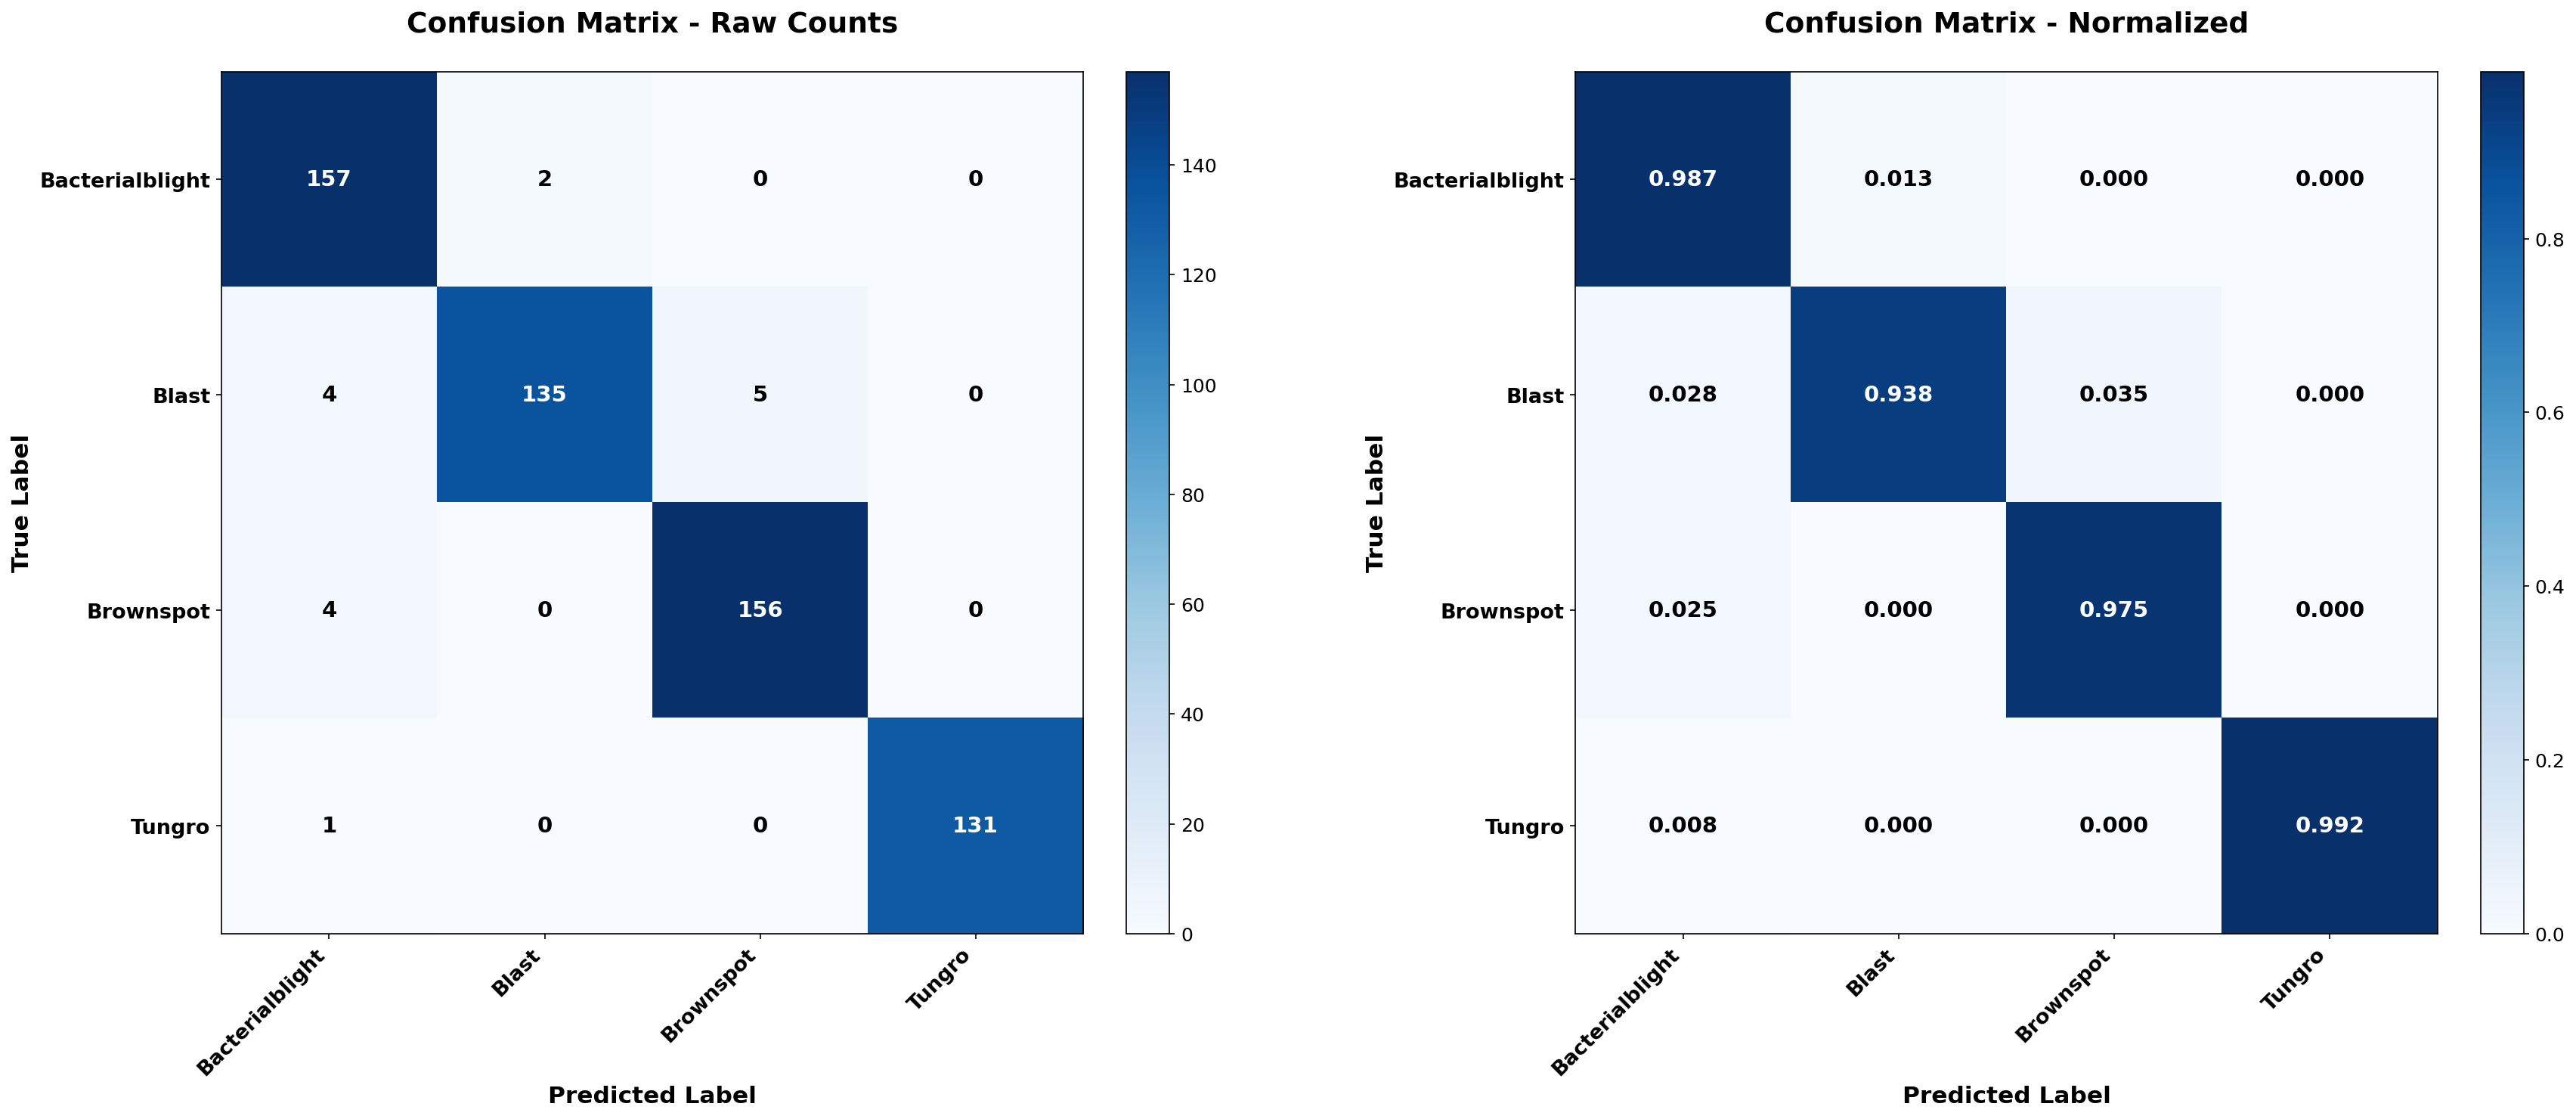


4. CLASSIFICATION REPORT

                 precision    recall  f1-score   support

Bacterialblight     0.9458    0.9874    0.9662       159
          Blast     0.9854    0.9375    0.9609       144
      Brownspot     0.9689    0.9750    0.9720       160
         Tungro     1.0000    0.9924    0.9962       132

       accuracy                         0.9731       595
      macro avg     0.9750    0.9731    0.9738       595
   weighted avg     0.9736    0.9731    0.9731       595

✓ Classification report saved to: evaluation_results/classification_report_evaluation.txt
✓ Classification report (JSON) saved to: evaluation_results/classification_report_evaluation.json

5. PREDICTING ON SAMPLE IMAGES

Generating predictions for 20 random samples...
✓ High-resolution sample predictions saved to: evaluation_results/sample_predictions.png


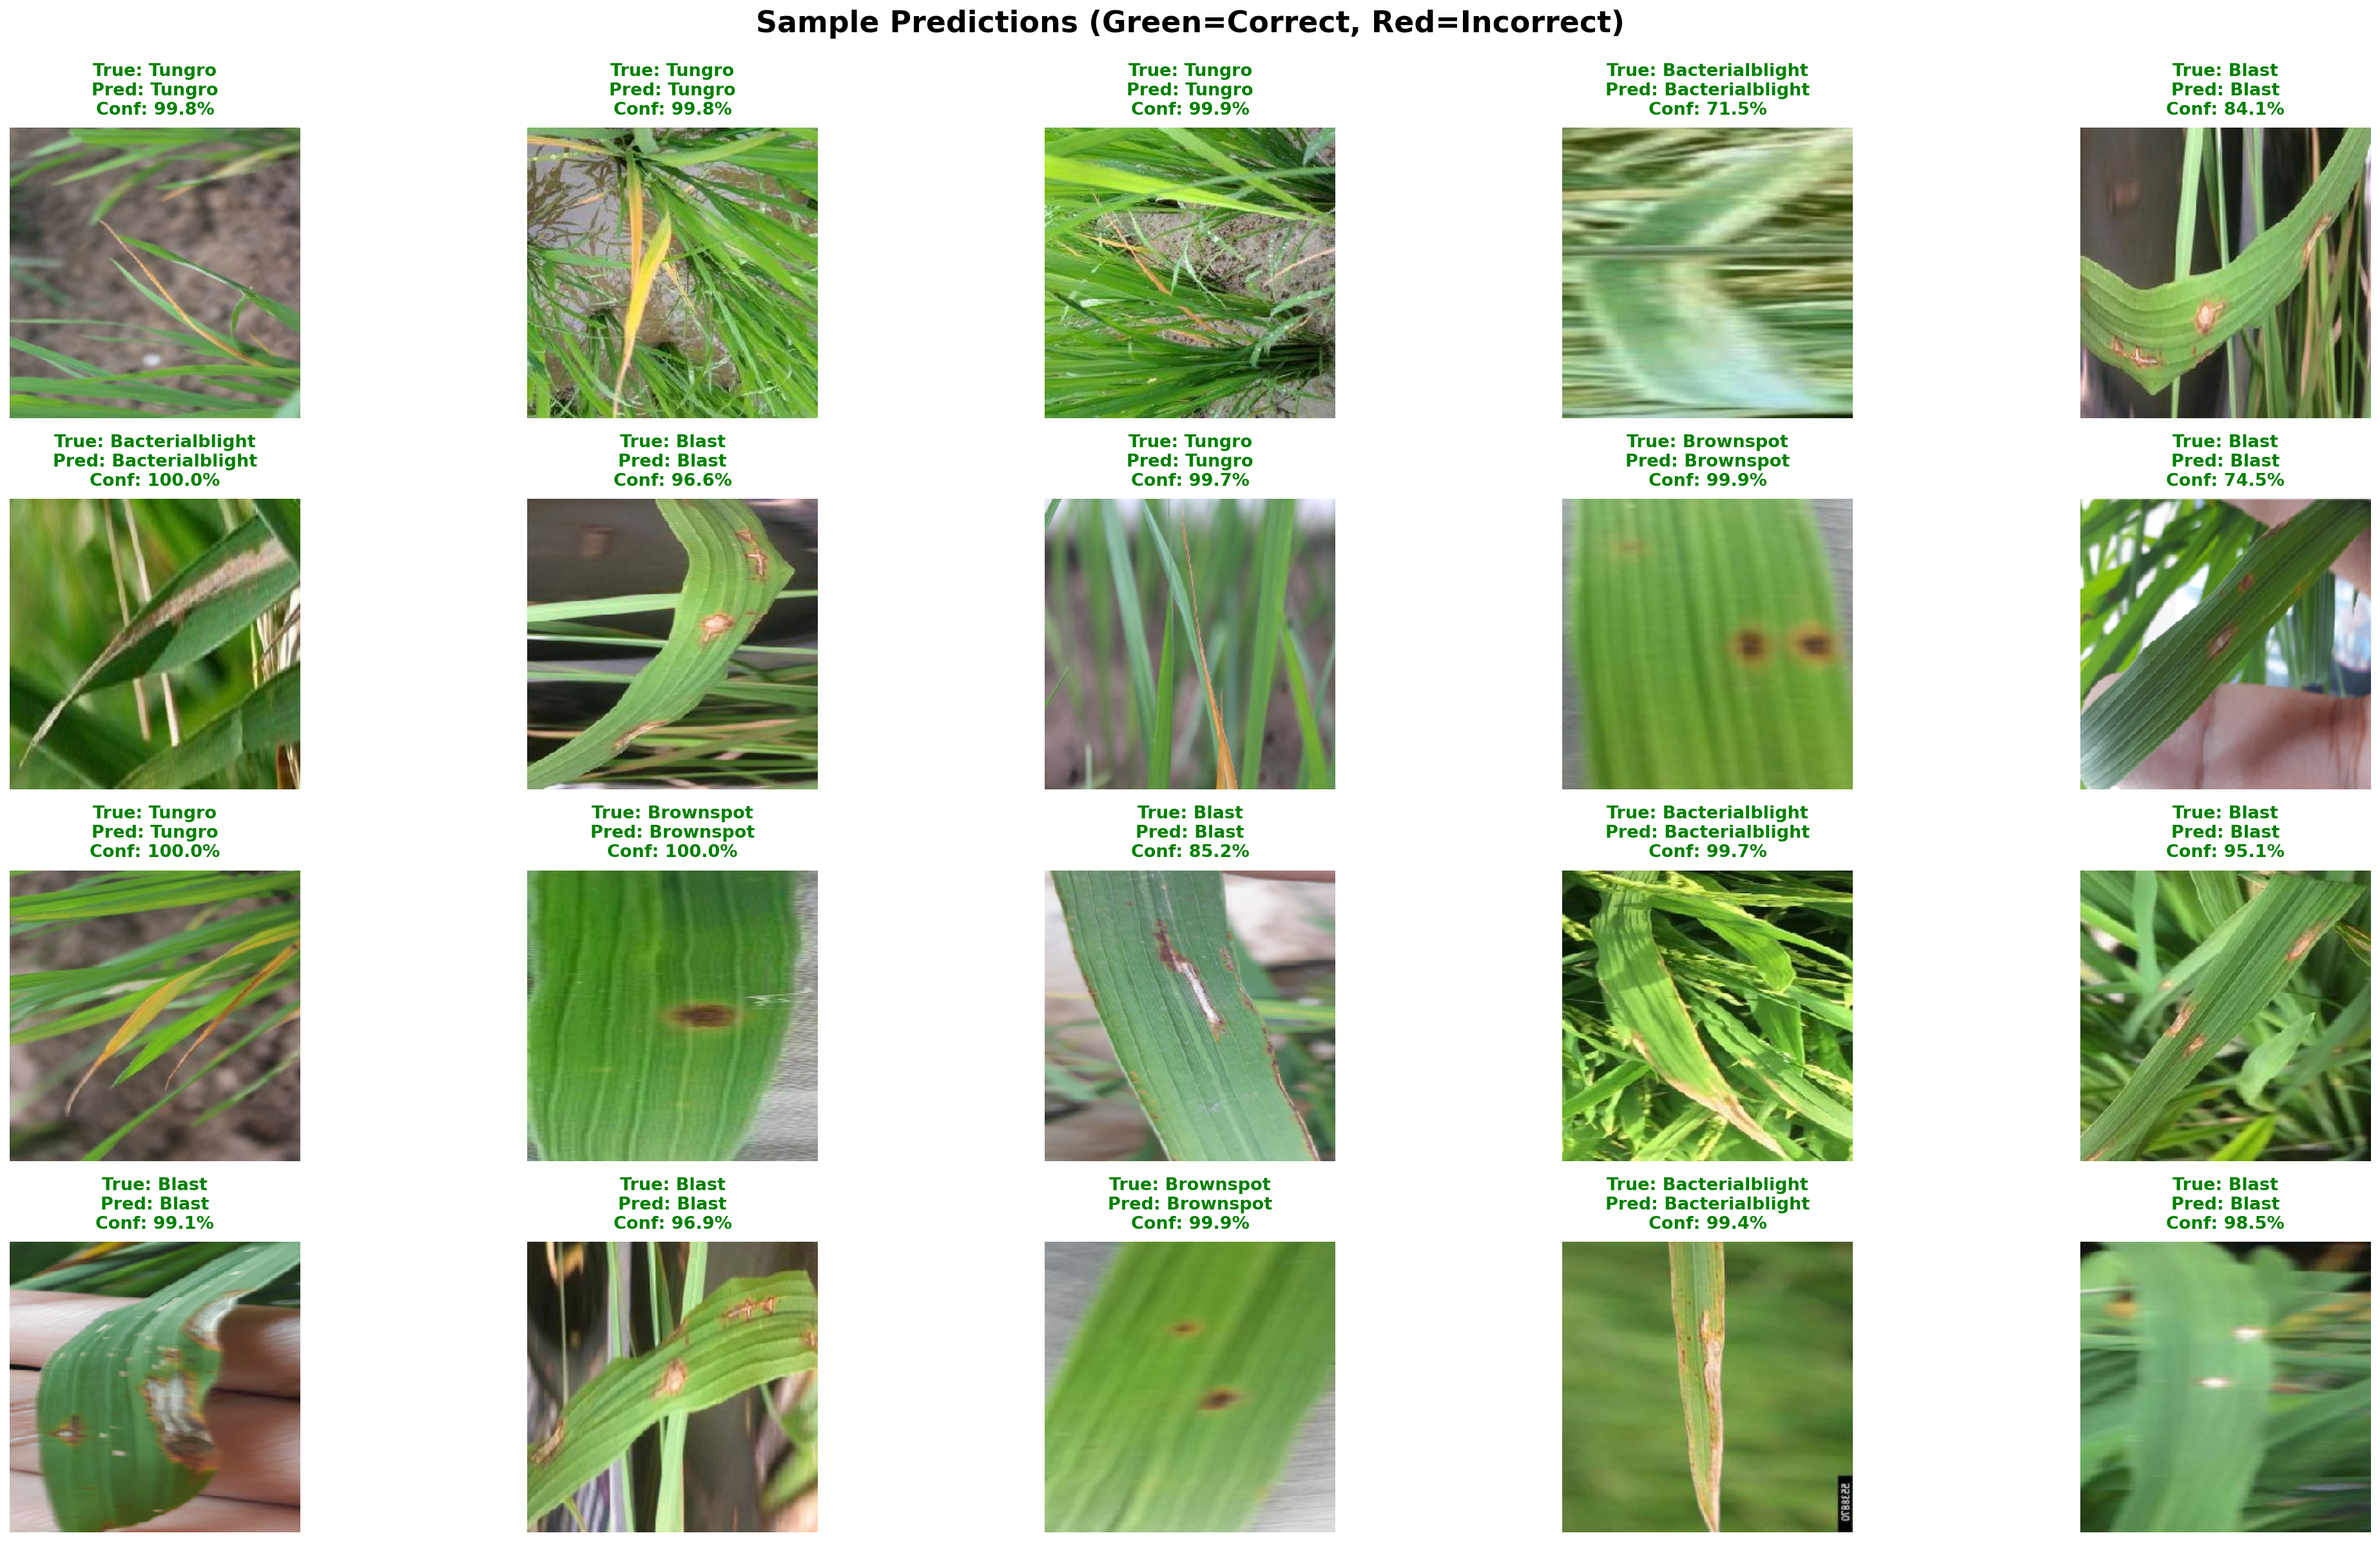


6. PREDICTING ON SPECIFIC IMAGES

Looking for sample images in test directory...
Found 6 sample images

Predicting image 1/6: BACTERAILBLIGHT3_026.jpg
  True Label: Bacterialblight
  Predicted: Bacterialblight
  Confidence: 40.21%
  Status: ✓ Correct

Predicting image 2/6: BACTERAILBLIGHT3_036.jpg
  True Label: Bacterialblight
  Predicted: Bacterialblight
  Confidence: 99.98%
  Status: ✓ Correct

Predicting image 3/6: BLAST1_026.jpg
  True Label: Blast
  Predicted: Blast
  Confidence: 97.99%
  Status: ✓ Correct

Predicting image 4/6: BLAST1_036.jpg
  True Label: Blast
  Predicted: Blast
  Confidence: 95.76%
  Status: ✓ Correct

Predicting image 5/6: BROWNSPOT1_026.jpg
  True Label: Brownspot
  Predicted: Brownspot
  Confidence: 99.69%
  Status: ✓ Correct

Predicting image 6/6: BROWNSPOT1_036.jpg
  True Label: Brownspot
  Predicted: Brownspot
  Confidence: 99.98%
  Status: ✓ Correct

✓ High-resolution individual predictions saved to: evaluation_results/individual_predictions.png


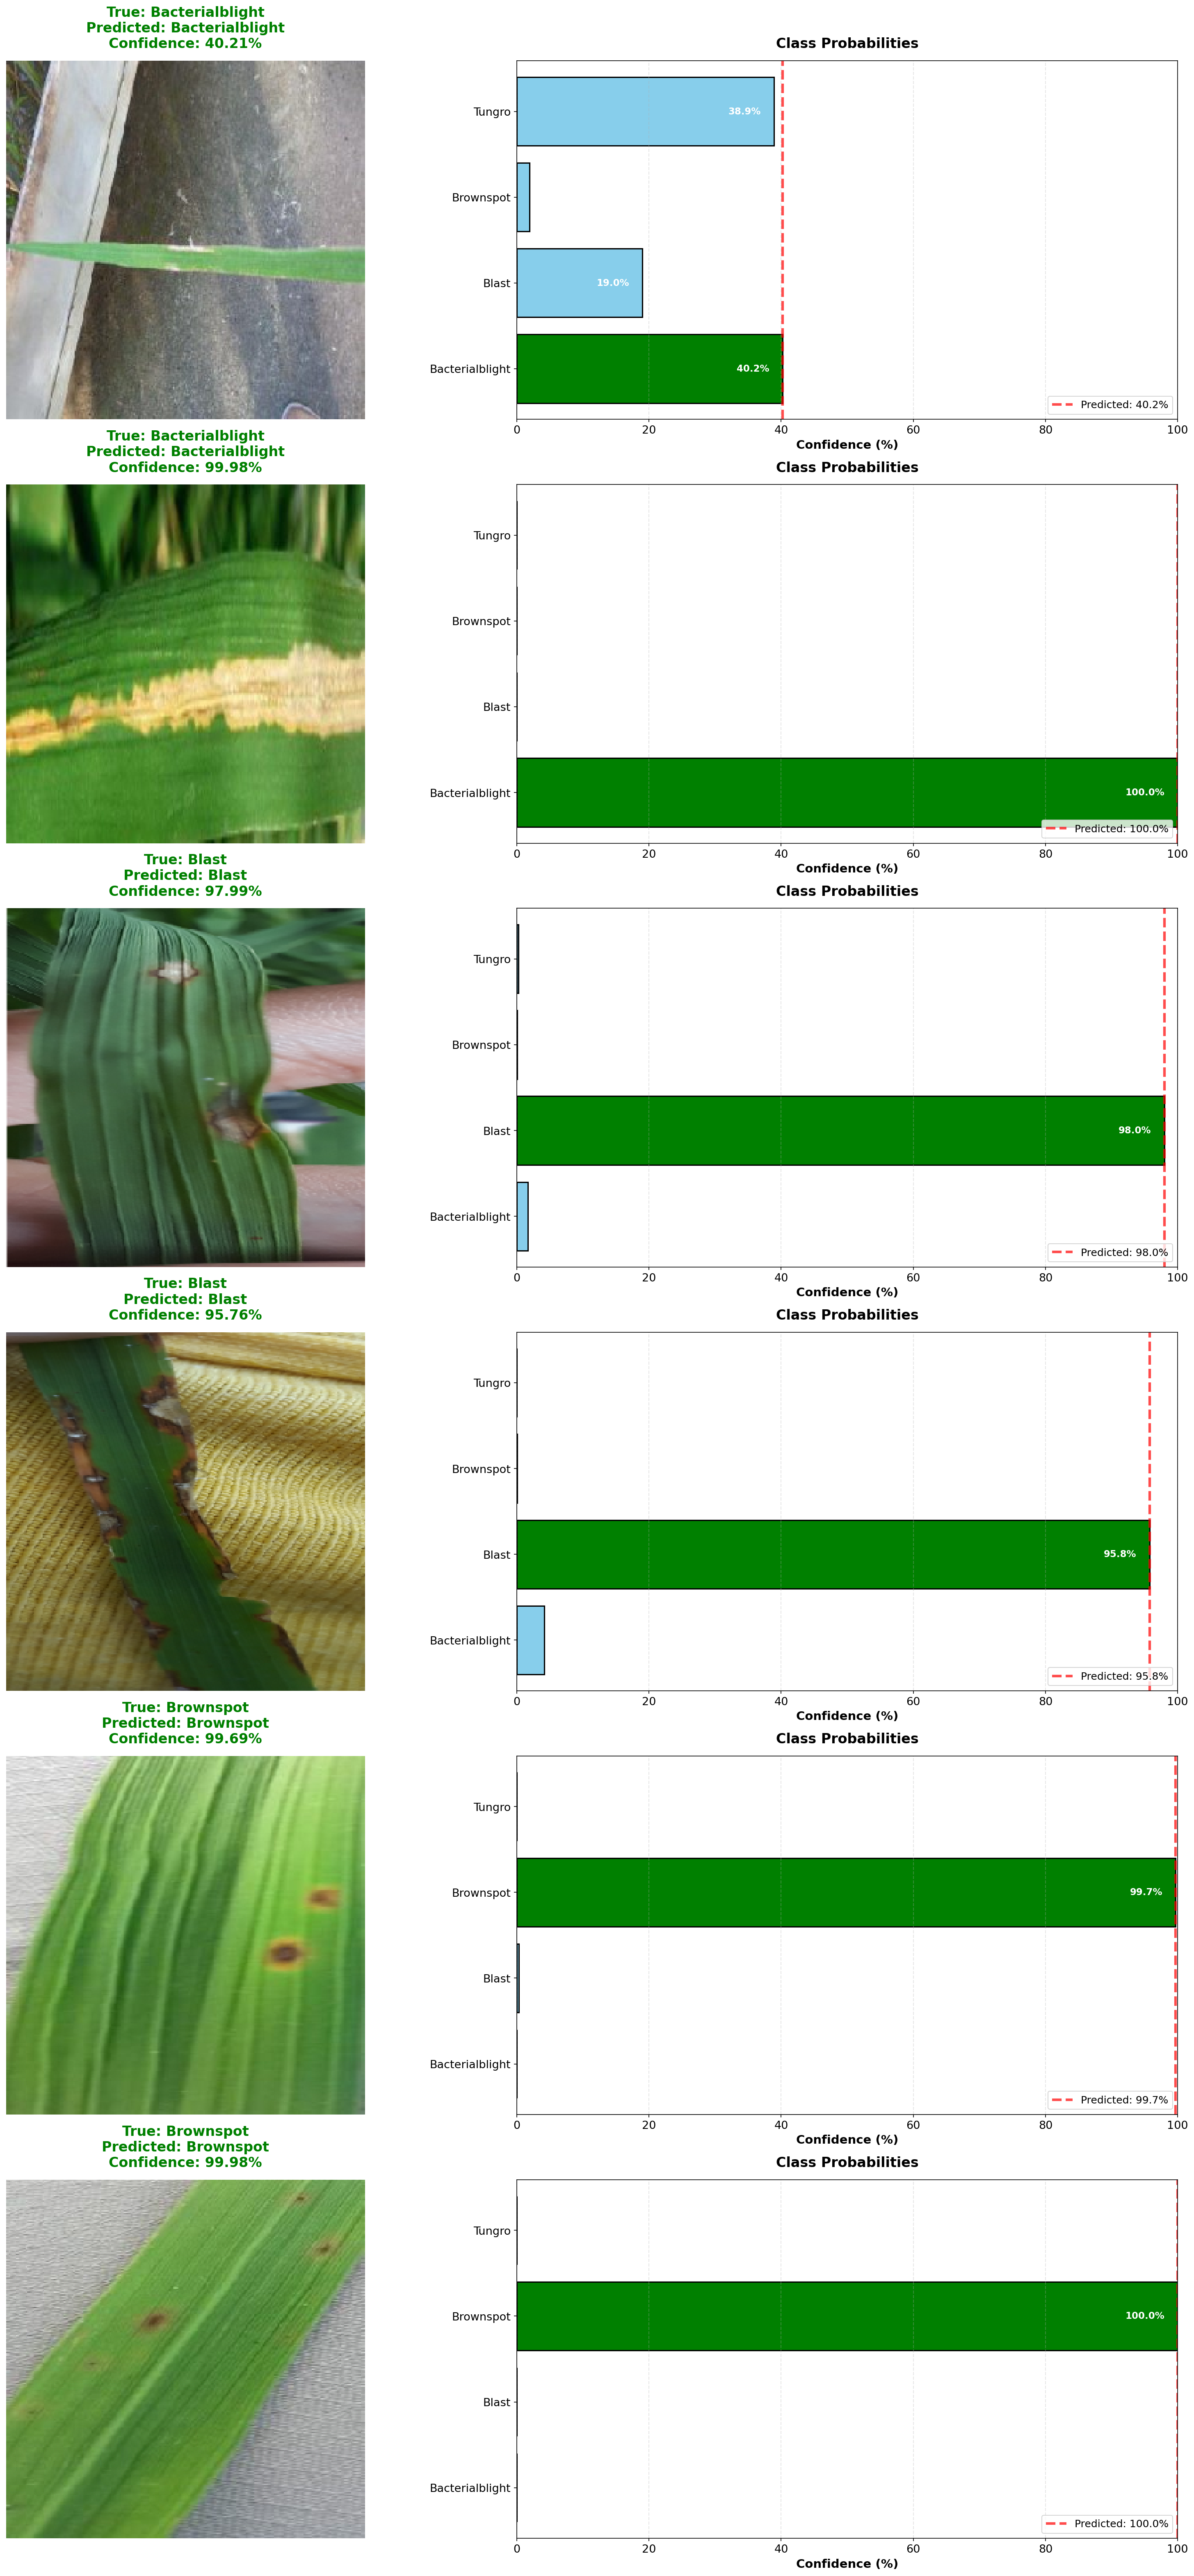


7. EVALUATION SUMMARY

+----------------------------------------------------+-----------------------------------------------------+
| Metric                                             | Value                                               |
+====================================================+=====================================================+
| ────────────────────────────────────────────────── | ──────────────────────────────                      |
+----------------------------------------------------+-----------------------------------------------------+
| Model Path                                         | saved_models/best_distilled_student_T10_seed3847.h5 |
+----------------------------------------------------+-----------------------------------------------------+
| ────────────────────────────────────────────────── | ──────────────────────────────                      |
+----------------------------------------------------+--------------------------------------------------

In [7]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt  # Fixed typo: matplotlib (not matpltlib)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tabulate import tabulate
import json
import os
import glob

# ============================
# Configuration
# ============================
Input_Image = 256
Channels = 3
batch_size = 32

print("="*80)
print("LOADING SAVED MODEL FOR EVALUATION")
print("="*80)

# ============================
# Load the Saved Model
# ============================
model_path = 'saved_models/best_distilled_student_T10_seed3847.h5'  # Update with your actual model name
print(f"\nLoading model from: {model_path}")

try:
    loaded_model = tf.keras.models.load_model(model_path)
    print("✓ Model loaded successfully!")
except Exception as e:
    print(f"✗ Error loading model: {e}")
    print("\nAvailable models in saved_models/:")
    for file in glob.glob('saved_models/*.h5'):
        print(f"  - {file}")
    exit(1)

# Load model info
info_path = 'saved_models/best_model_info_T10.json'
if os.path.exists(info_path):
    with open(info_path, 'r') as f:
        model_info = json.load(f)
    print(f"✓ Model info loaded")
    print(f"\nModel Details:")
    print(f"  Temperature: {model_info['temperature']}")
    print(f"  Training Seed: {model_info['best_seed']}")
    print(f"  Training Accuracy: {model_info['best_accuracy']:.2f}%")
    print(f"  Training Loss: {model_info['best_loss']:.4f}")
else:
    print("⚠ Model info file not found")
    model_info = {}

# Display model architecture summary
print("\n" + "="*80)
print("MODEL ARCHITECTURE")
print("="*80)
loaded_model.summary()

# ============================
# Compile the Model (Required for evaluate())
# ============================
print("\n" + "="*80)
print("COMPILING MODEL")
print("="*80)

loaded_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("✓ Model compiled successfully!")

# ============================
# Load Test Data
# ============================
print("\n" + "="*80)
print("LOADING TEST DATA")
print("="*80)

test_data = ImageDataGenerator(rescale=1./255)

test_set = test_data.flow_from_directory(
    "test",
    target_size=(Input_Image, Input_Image),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

class_names = list(test_set.class_indices.keys())
num_classes = len(class_names)

print(f"\n✓ Test set loaded")
print(f"  Total test samples: {test_set.samples}")
print(f"  Number of classes: {num_classes}")
print(f"  Class names: {class_names}")
print(f"  Batch size: {batch_size}")

# ============================
# 1. EVALUATE MODEL - GET TEST ACCURACY
# ============================
print("\n" + "="*80)
print("1. EVALUATING MODEL ON TEST SET")
print("="*80)

test_set.reset()
test_loss, test_accuracy = loaded_model.evaluate(test_set, verbose=1)

print(f"\n{'='*60}")
print("TEST SET PERFORMANCE")
print(f"{'='*60}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"{'='*60}")

# ============================
# 2. GENERATE PREDICTIONS FOR CONFUSION MATRIX AND CLASSIFICATION REPORT
# ============================
print("\n" + "="*80)
print("2. GENERATING PREDICTIONS")
print("="*80)

test_set.reset()
y_true = []
y_pred = []
y_pred_probs = []

print("\nGenerating predictions...")
for batch_idx in range(len(test_set)):
    x_batch, y_batch = test_set.next()
    predictions = loaded_model.predict(x_batch, verbose=0)
    
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))
    y_pred_probs.extend(predictions)
    
    if (batch_idx + 1) % 10 == 0:
        print(f"  Processed {(batch_idx + 1) * batch_size}/{test_set.samples} samples...")

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_probs = np.array(y_pred_probs)

print(f"\n✓ Predictions complete for {len(y_true)} samples")

# Verify accuracy calculation
calculated_accuracy = accuracy_score(y_true, y_pred) * 100
print(f"✓ Calculated Accuracy: {calculated_accuracy:.2f}%")

# ============================
# 3. CONFUSION MATRIX
# ============================
print("\n" + "="*80)
print("3. CONFUSION MATRIX")
print("="*80)

cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

print("\nConfusion Matrix (Raw Counts):")
print(cm)
print("\nConfusion Matrix (Normalized):")
print(cm_normalized.round(3))

# Visualize confusion matrices with HIGH RESOLUTION
# Set high-quality matplotlib parameters
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Raw confusion matrix
im1 = axes[0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title('Confusion Matrix - Raw Counts', fontsize=18, fontweight='bold', pad=25)
axes[0].set_xlabel('Predicted Label', fontsize=15, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=15, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.ax.tick_params(labelsize=12)

tick_marks = np.arange(num_classes)
axes[0].set_xticks(tick_marks)
axes[0].set_yticks(tick_marks)
axes[0].set_xticklabels(class_names, rotation=45, ha='right', fontsize=13, fontweight='bold')
axes[0].set_yticklabels(class_names, fontsize=13, fontweight='bold')

thresh = cm.max() / 2.
font_size = 14 if num_classes <= 10 else (10 if num_classes <= 20 else 8)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=font_size, fontweight='bold')

# Normalized confusion matrix
im2 = axes[1].imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title('Confusion Matrix - Normalized', fontsize=18, fontweight='bold', pad=25)
axes[1].set_xlabel('Predicted Label', fontsize=15, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=15, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.ax.tick_params(labelsize=12)

axes[1].set_xticks(tick_marks)
axes[1].set_yticks(tick_marks)
axes[1].set_xticklabels(class_names, rotation=45, ha='right', fontsize=13, fontweight='bold')
axes[1].set_yticklabels(class_names, fontsize=13, fontweight='bold')

thresh_norm = cm_normalized.max() / 2.
for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):
        axes[1].text(j, i, format(cm_normalized[i, j], '.3f'),
                    ha="center", va="center",
                    color="white" if cm_normalized[i, j] > thresh_norm else "black",
                    fontsize=font_size, fontweight='bold')

plt.tight_layout()
cm_save_path = 'evaluation_results/confusion_matrix_evaluation.png'
os.makedirs('evaluation_results', exist_ok=True)
plt.savefig(cm_save_path, dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"\n✓ High-resolution confusion matrix saved to: {cm_save_path}")
plt.show()
plt.close()

# ============================
# 4. CLASSIFICATION REPORT
# ============================
print("\n" + "="*80)
print("4. CLASSIFICATION REPORT")
print("="*80 + "\n")

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

report_dict = classification_report(y_true, y_pred, target_names=class_names, 
                                   digits=4, output_dict=True)

# Save classification report
report_save_path = 'evaluation_results/classification_report_evaluation.txt'
with open(report_save_path, 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("CLASSIFICATION REPORT - MODEL EVALUATION\n")
    f.write("="*80 + "\n\n")
    f.write(f"Model Path: {model_path}\n")
    f.write(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write(f"Total Samples: {len(y_true)}\n\n")
    f.write("="*80 + "\n")
    f.write(report)

print(f"✓ Classification report saved to: {report_save_path}")

# Save as JSON
report_json_path = 'evaluation_results/classification_report_evaluation.json'
with open(report_json_path, 'w') as f:
    json.dump(report_dict, f, indent=4)
print(f"✓ Classification report (JSON) saved to: {report_json_path}")

# ============================
# 5. PREDICT ON SAMPLE IMAGES
# ============================
print("\n" + "="*80)
print("5. PREDICTING ON SAMPLE IMAGES")
print("="*80)

# Get some random sample indices
num_samples = min(20, len(y_true))  # Show up to 20 samples
sample_indices = np.random.choice(len(y_true), num_samples, replace=False)

print(f"\nGenerating predictions for {num_samples} random samples...")

# Create figure for sample predictions - HIGH RESOLUTION
fig = plt.figure(figsize=(28, 16))
rows = 4
cols = 5

for idx, sample_idx in enumerate(sample_indices[:rows*cols]):
    # Get the image
    batch_idx = sample_idx // batch_size
    within_batch_idx = sample_idx % batch_size
    
    test_set.reset()
    for _ in range(batch_idx + 1):
        x_batch, y_batch = test_set.next()
    
    img = x_batch[within_batch_idx]
    true_label = class_names[y_true[sample_idx]]
    pred_label = class_names[y_pred[sample_idx]]
    confidence = y_pred_probs[sample_idx][y_pred[sample_idx]] * 100
    
    # Create subplot
    ax = plt.subplot(rows, cols, idx + 1)
    plt.imshow(img)
    
    # Set title with color based on correctness
    is_correct = y_true[sample_idx] == y_pred[sample_idx]
    title_color = 'green' if is_correct else 'red'
    title = f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%"
    
    plt.title(title, fontsize=13, color=title_color, fontweight='bold', pad=10)
    plt.axis('off')
    
    # Add border to highlight correct/incorrect
    for spine in ax.spines.values():
        spine.set_edgecolor(title_color)
        spine.set_linewidth(4)
        spine.set_visible(True)

plt.suptitle('Sample Predictions (Green=Correct, Red=Incorrect)', 
             fontsize=22, fontweight='bold', y=0.995)
plt.tight_layout()
samples_save_path = 'evaluation_results/sample_predictions.png'
plt.savefig(samples_save_path, dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"✓ High-resolution sample predictions saved to: {samples_save_path}")
plt.show()
plt.close()

# ============================
# 6. PREDICT ON SPECIFIC IMAGES FROM FOLDER
# ============================
print("\n" + "="*80)
print("6. PREDICTING ON SPECIFIC IMAGES")
print("="*80)

def predict_single_image(image_path, model, class_names, display=True):
    """
    Predict class for a single image
    
    Args:
        image_path: Path to the image file
        model: Trained model
        class_names: List of class names
        display: Whether to display the image with prediction
    
    Returns:
        dict with prediction results
    """
    try:
        # Load and preprocess image
        img = load_img(image_path, target_size=(Input_Image, Input_Image))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        # Make prediction
        predictions = model.predict(img_array, verbose=0)
        predicted_class_idx = np.argmax(predictions[0])
        predicted_class = class_names[predicted_class_idx]
        confidence = predictions[0][predicted_class_idx] * 100
        
        # Get top 3 predictions
        top_3_idx = np.argsort(predictions[0])[-3:][::-1]
        top_3_predictions = [(class_names[i], predictions[0][i] * 100) for i in top_3_idx]
        
        result = {
            'image_path': image_path,
            'predicted_class': predicted_class,
            'confidence': confidence,
            'top_3_predictions': top_3_predictions,
            'all_probabilities': {class_names[i]: float(predictions[0][i] * 100) 
                                 for i in range(len(class_names))}
        }
        
        # Display if requested
        if display:
            plt.figure(figsize=(10, 6))
            
            # Display image
            plt.subplot(1, 2, 1)
            plt.imshow(img)
            plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}%",
                     fontsize=16, fontweight='bold', pad=15)
            plt.axis('off')
            
            # Display probabilities
            plt.subplot(1, 2, 2)
            classes = list(result['all_probabilities'].keys())
            probs = list(result['all_probabilities'].values())
            colors = ['green' if c == predicted_class else 'skyblue' for c in classes]
            
            plt.barh(classes, probs, color=colors, edgecolor='black', linewidth=1.5)
            plt.xlabel('Confidence (%)', fontsize=14, fontweight='bold')
            plt.title('Class Probabilities', fontsize=16, fontweight='bold', pad=15)
            plt.xlim([0, 100])
            plt.grid(axis='x', alpha=0.3)
            plt.tick_params(labelsize=12)
            
            plt.tight_layout()
            plt.savefig('evaluation_results/temp_prediction.png', dpi=600, bbox_inches='tight', 
                       facecolor='white', edgecolor='none')
            plt.show()
            plt.close()
        
        return result
        
    except Exception as e:
        print(f"Error predicting image {image_path}: {e}")
        return None

# Example: Predict on images from test set folders
print("\nLooking for sample images in test directory...")

sample_images = []
for class_name in class_names[:3]:  # Take first 3 classes
    class_path = os.path.join("test", class_name)
    if os.path.exists(class_path):
        images = glob.glob(os.path.join(class_path, "*.*"))[:2]  # Take 2 images per class
        sample_images.extend(images)

if sample_images:
    print(f"Found {len(sample_images)} sample images")
    
    # Create a comprehensive prediction display - HIGH RESOLUTION
    fig, axes = plt.subplots(len(sample_images), 2, figsize=(22, 7*len(sample_images)))
    if len(sample_images) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, img_path in enumerate(sample_images):
        print(f"\nPredicting image {idx+1}/{len(sample_images)}: {os.path.basename(img_path)}")
        
        # Load and preprocess
        img = load_img(img_path, target_size=(Input_Image, Input_Image))
        img_array = img_to_array(img) / 255.0
        img_array_batch = np.expand_dims(img_array, axis=0)
        
        # Predict
        predictions = loaded_model.predict(img_array_batch, verbose=0)
        predicted_class_idx = np.argmax(predictions[0])
        predicted_class = class_names[predicted_class_idx]
        confidence = predictions[0][predicted_class_idx] * 100
        
        # Get true label from path
        true_class = os.path.basename(os.path.dirname(img_path))
        is_correct = (predicted_class == true_class)
        
        print(f"  True Label: {true_class}")
        print(f"  Predicted: {predicted_class}")
        print(f"  Confidence: {confidence:.2f}%")
        print(f"  Status: {'✓ Correct' if is_correct else '✗ Incorrect'}")
        
        # Display image with border
        axes[idx, 0].imshow(img)
        title_color = 'green' if is_correct else 'red'
        axes[idx, 0].set_title(
            f"True: {true_class}\nPredicted: {predicted_class}\nConfidence: {confidence:.2f}%",
            fontsize=16, fontweight='bold', color=title_color, pad=15
        )
        axes[idx, 0].axis('off')
        
        # Add colored border
        for spine in axes[idx, 0].spines.values():
            spine.set_edgecolor(title_color)
            spine.set_linewidth(5)
            spine.set_visible(True)
        
        # Display probability distribution
        all_probs = predictions[0] * 100
        colors_bar = ['green' if i == predicted_class_idx else 'skyblue' 
                     for i in range(len(class_names))]
        
        bars = axes[idx, 1].barh(class_names, all_probs, color=colors_bar, 
                                 edgecolor='black', linewidth=1.5)
        axes[idx, 1].set_xlabel('Confidence (%)', fontsize=14, fontweight='bold')
        axes[idx, 1].set_title('Class Probabilities', fontsize=16, fontweight='bold', pad=15)
        axes[idx, 1].set_xlim([0, 100])
        axes[idx, 1].grid(axis='x', alpha=0.3, linestyle='--', linewidth=1)
        axes[idx, 1].tick_params(labelsize=13)
        
        # Add value labels on bars
        for bar, prob in zip(bars, all_probs):
            width = bar.get_width()
            if width > 5:  # Only show label if bar is wide enough
                axes[idx, 1].text(width - 2, bar.get_y() + bar.get_height()/2,
                                f'{prob:.1f}%',
                                ha='right', va='center', 
                                fontsize=11, fontweight='bold', color='white')
        
        # Highlight predicted class
        axes[idx, 1].axvline(x=confidence, color='red', linestyle='--', 
                            linewidth=3, alpha=0.7, label=f'Predicted: {confidence:.1f}%')
        axes[idx, 1].legend(fontsize=12, loc='lower right')
    
    plt.tight_layout()
    individual_pred_path = 'evaluation_results/individual_predictions.png'
    plt.savefig(individual_pred_path, dpi=600, bbox_inches='tight', 
               facecolor='white', edgecolor='none')
    print(f"\n✓ High-resolution individual predictions saved to: {individual_pred_path}")
    plt.show()
    plt.close()
else:
    print("No sample images found in test directory")
    print("\nTo predict on your own images, use:")
    print("  result = predict_single_image('path/to/your/image.jpg', loaded_model, class_names)")

# ============================
# 7. SUMMARY TABLE
# ============================
print("\n" + "="*80)
print("7. EVALUATION SUMMARY")
print("="*80 + "\n")

summary_data = [
    ["Metric", "Value"],
    ["─"*50, "─"*30],
    ["Model Path", model_path],
    ["─"*50, "─"*30],
    ["Test Accuracy", f"{test_accuracy*100:.2f}%"],
    ["Test Loss", f"{test_loss:.4f}"],
    ["Total Test Samples", f"{len(y_true)}"],
    ["Number of Classes", f"{num_classes}"],
    ["─"*50, "─"*30],
    ["Macro Avg Precision", f"{report_dict['macro avg']['precision']:.4f}"],
    ["Macro Avg Recall", f"{report_dict['macro avg']['recall']:.4f}"],
    ["Macro Avg F1-Score", f"{report_dict['macro avg']['f1-score']:.4f}"],
    ["─"*50, "─"*30],
    ["Weighted Avg Precision", f"{report_dict['weighted avg']['precision']:.4f}"],
    ["Weighted Avg Recall", f"{report_dict['weighted avg']['recall']:.4f}"],
    ["Weighted Avg F1-Score", f"{report_dict['weighted avg']['f1-score']:.4f}"],
]

print(tabulate(summary_data, headers="firstrow", tablefmt="grid"))

# Save summary
summary_save_path = 'evaluation_results/evaluation_summary.txt'
with open(summary_save_path, 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("MODEL EVALUATION SUMMARY\n")
    f.write("="*80 + "\n\n")
    f.write(tabulate(summary_data, headers="firstrow", tablefmt="grid"))
    f.write("\n\n")
    f.write("Generated Files:\n")
    f.write(f"  - Confusion Matrix: {cm_save_path}\n")
    f.write(f"  - Classification Report (TXT): {report_save_path}\n")
    f.write(f"  - Classification Report (JSON): {report_json_path}\n")
    f.write(f"  - Sample Predictions: {samples_save_path}\n")
    if sample_images:
        f.write(f"  - Individual Predictions: {individual_pred_path}\n")
    f.write(f"  - Summary: {summary_save_path}\n")

print(f"\n✓ Evaluation summary saved to: {summary_save_path}")

print("\n" + "="*80)
print("EVALUATION COMPLETE!")
print("="*80)
print(f"All results saved in: evaluation_results/")
print("="*80)

19/19 [==============================] - 1s 32ms/step


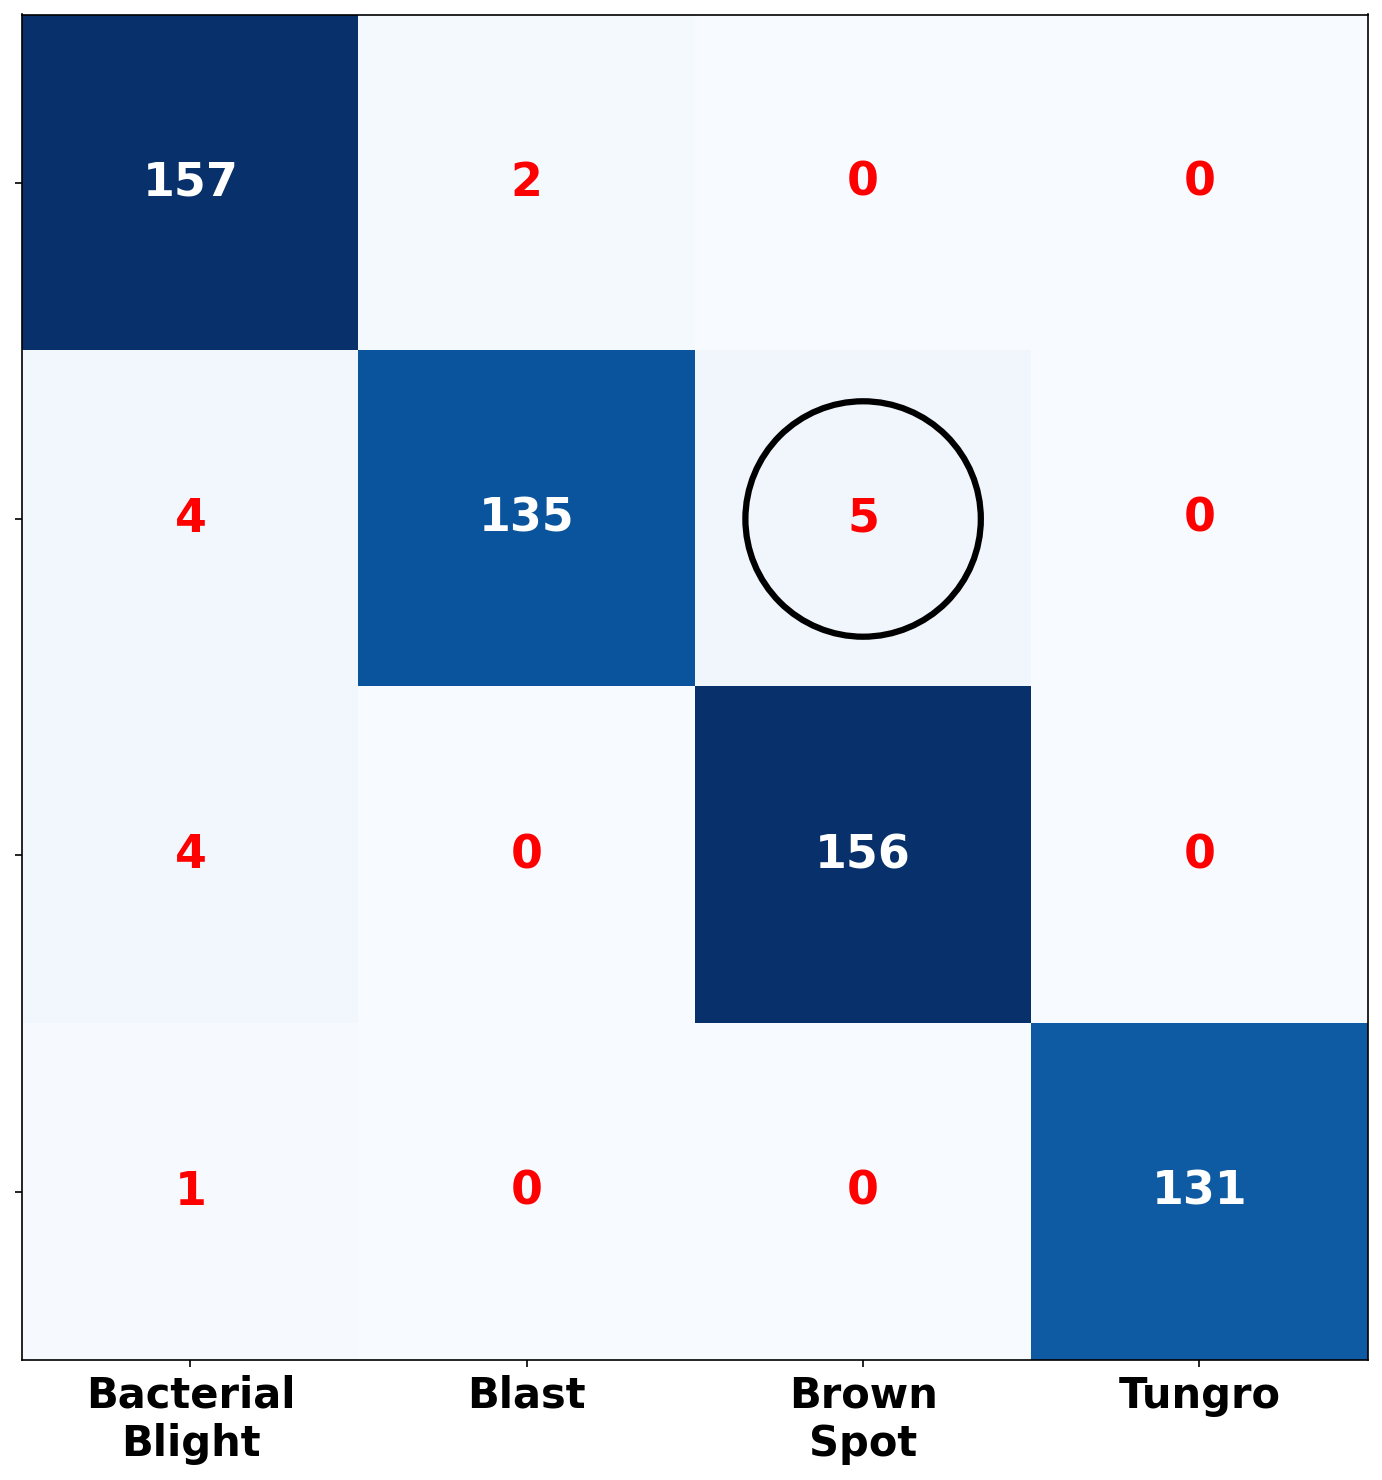

Classification Report for Distiller Model:
                   precision    recall  f1-score   support

Bacterial Blight       0.95      0.99      0.97       159
           Blast       0.99      0.94      0.96       144
      Brown Spot       0.97      0.97      0.97       160
          Tungro       1.00      0.99      1.00       132

        accuracy                           0.97       595
       macro avg       0.98      0.97      0.97       595
    weighted avg       0.97      0.97      0.97       595



In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load the saved distiller model
distiller_model = tf.keras.models.load_model(r'saved_models\best_distilled_student_T10_seed1918.h5')

# Compile the model (required for evaluate)
distiller_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Evaluate the model on the test set
test_set.reset()
distiller_model.evaluate(test_set)

# Extract test data and labels
def extract_test_data(generator):
    generator.reset()
    data_list = []
    labels_list = []
    for _ in range(len(generator)):
        data, labels = generator.next()
        data_list.append(data)
        labels_list.append(labels)
    x_test = np.vstack(data_list)
    y_test = np.vstack(labels_list)
    return x_test, y_test

x_test, y_test = extract_test_data(test_set)

# Generate predictions
y_pred_probs = distiller_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Update class names to split 'Bacterial Blight' into two lines
classes = {0: "Bacterial\nBlight", 1: "Blast", 2: "Brown\nSpot", 3: "Tungro"}

# Plot the confusion matrix
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar().remove()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, [classes[i] for i in range(len(classes))], rotation=0, fontsize=20, fontweight='bold')
plt.yticks(tick_marks, [''] * len(classes))  # Remove y-axis labels

# Print confusion matrix values
thresh = cm.max() / 2.
for i in range(len(classes)):
    for j in range(len(classes)):
        text_color = 'red' if i != j else 'white'
        plt.text(j, i, str(cm[i, j]), 
                ha='center', va='center', 
                fontsize=22, fontweight='bold', 
                color=text_color)

# Add a circle in the 2nd row, 3rd column (index (1, 2))
circle = plt.Circle((2, 1), 0.35, color='black', fill=False, linewidth=3)
plt.gca().add_patch(circle)

plt.tight_layout()
plt.show()

# Print classification report
class_names_original = ['Bacterial Blight', 'Blast', 'Brown Spot', 'Tungro']
report = classification_report(y_true, y_pred, target_names=class_names_original)
print("Classification Report for Distiller Model:\n", report)

19/19 [==============================] - 1s 31ms/step


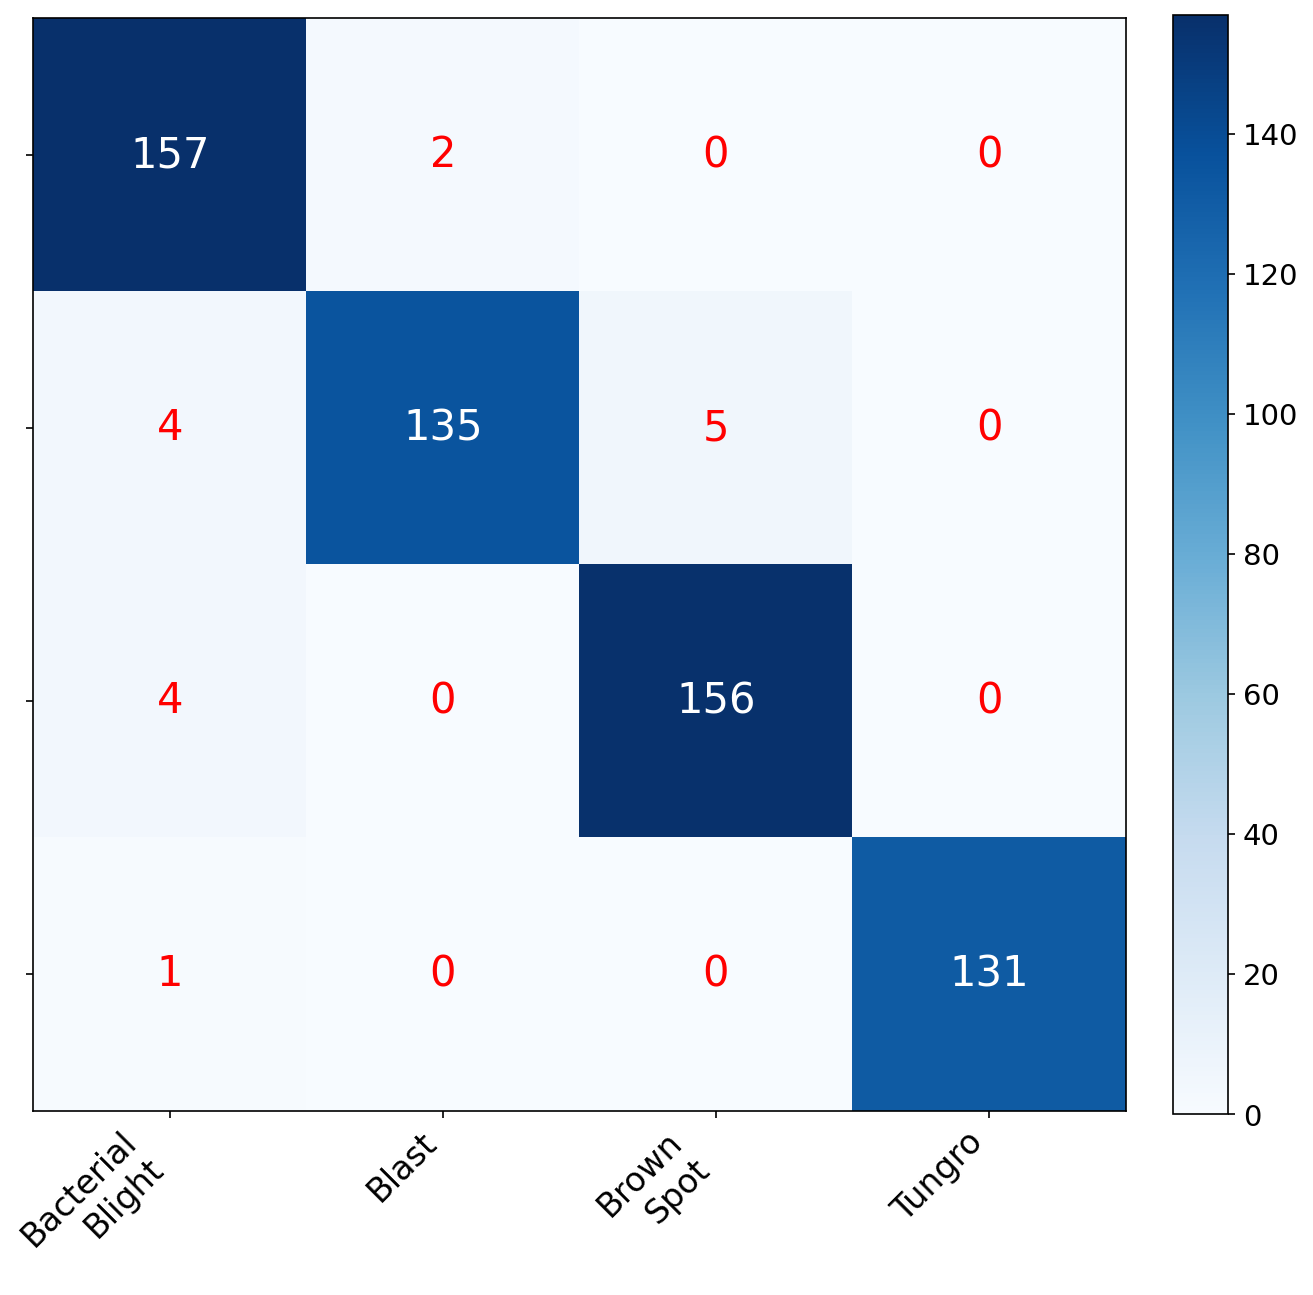

Classification Report for Distiller Model:
                   precision    recall  f1-score   support

Bacterial Blight       0.95      0.99      0.97       159
           Blast       0.99      0.94      0.96       144
      Brown Spot       0.97      0.97      0.97       160
          Tungro       1.00      0.99      1.00       132

        accuracy                           0.97       595
       macro avg       0.98      0.97      0.97       595
    weighted avg       0.97      0.97      0.97       595



In [22]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load the saved distiller model
distiller_model = tf.keras.models.load_model(r'saved_models\best_distilled_student_T10_seed1918.h5')

# Compile the model (required for evaluate)
distiller_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Evaluate the model on the test set
test_set.reset()
distiller_model.evaluate(test_set)

# Extract test data and labels
def extract_test_data(generator):
    generator.reset()
    data_list = []
    labels_list = []
    for _ in range(len(generator)):
        data, labels = generator.next()
        data_list.append(data)
        labels_list.append(labels)
    x_test = np.vstack(data_list)
    y_test = np.vstack(labels_list)
    return x_test, y_test

x_test, y_test = extract_test_data(test_set)

# Generate predictions
y_pred_probs = distiller_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Update class names to split 'Bacterial Blight' into two lines
classes = {0: "Bacterial\nBlight", 1: "Blast", 2: "Brown\nSpot", 3: "Tungro"}

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(9, 9))

# Use Blues colormap
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

# Add colorbar on the right
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=14)

# Set ticks
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)

# X-axis labels
x_labels = [classes[i] for i in range(len(classes))]
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=16)
ax.set_yticklabels([''] * len(classes))  # Remove y-axis labels

# Print confusion matrix values
thresh = cm.max() / 2.
for i in range(len(classes)):
    for j in range(len(classes)):
        text_color = 'red' if i != j else 'white'
        ax.text(j, i, str(cm[i, j]), 
                ha='center', va='center', 
                fontsize=20,  
                color=text_color)

# Add a circle in the 2nd row, 3rd column (index (1, 2))
#circle = plt.Circle((0, 3), 0.35, color='black', fill=False, linewidth=3)
#ax.add_patch(circle)

plt.tight_layout()
plt.show()

# Print classification report
class_names_original = ['Bacterial Blight', 'Blast', 'Brown Spot', 'Tungro']
report = classification_report(y_true, y_pred, target_names=class_names_original)
print("Classification Report for Distiller Model:\n", report)

In [2]:
import random
import numpy as np
import tensorflow as tf
import time
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tabulate import tabulate
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
import json
import os

# ============================
# Configuration
# ============================
Input_Image = 256
Channels = 3
batch_size = 32
epochs = 30

# ============================
# Generate random seeds from system time
# ============================
# Use current nanoseconds to generate 5 random seeds
base_seed = int(time.time_ns() % 100000)
print(f"Base seed from system time: {base_seed}")

random.seed(base_seed)
seeds = [random.randint(1000, 9999) for _ in range(5)]
print(f"Randomly selected seeds: {seeds}")
print(f"{'='*60}\n")

# ============================
# Data Generators
# ============================
# Data augmentation for training set
train_data = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    shear_range=0.2,
    zoom_range=0.2,
    vertical_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

# Validation and test sets
common_data = ImageDataGenerator(rescale=1./255)

# Test set (will be the same for all runs)
print("Loading test set...")
test_set = common_data.flow_from_directory(
    "test",
    target_size=(Input_Image, Input_Image),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,  # No shuffle for consistent evaluation
    seed=42  # Fixed seed for reproducibility of test set
)

# Validation set (will be the same for all runs)
print("Loading validation set...")
val_set = common_data.flow_from_directory(
    "val",
    target_size=(Input_Image, Input_Image),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    seed=42  # Fixed seed for reproducibility
)

# Input shape
input_shape = (Input_Image, Input_Image, Channels)

Base seed from system time: 43300
Randomly selected seeds: [3185, 4304, 8863, 2388, 9685]

Loading test set...
Found 595 images belonging to 4 classes.
Loading validation set...
Found 592 images belonging to 4 classes.


19/19 [==============================] - 1s 31ms/step


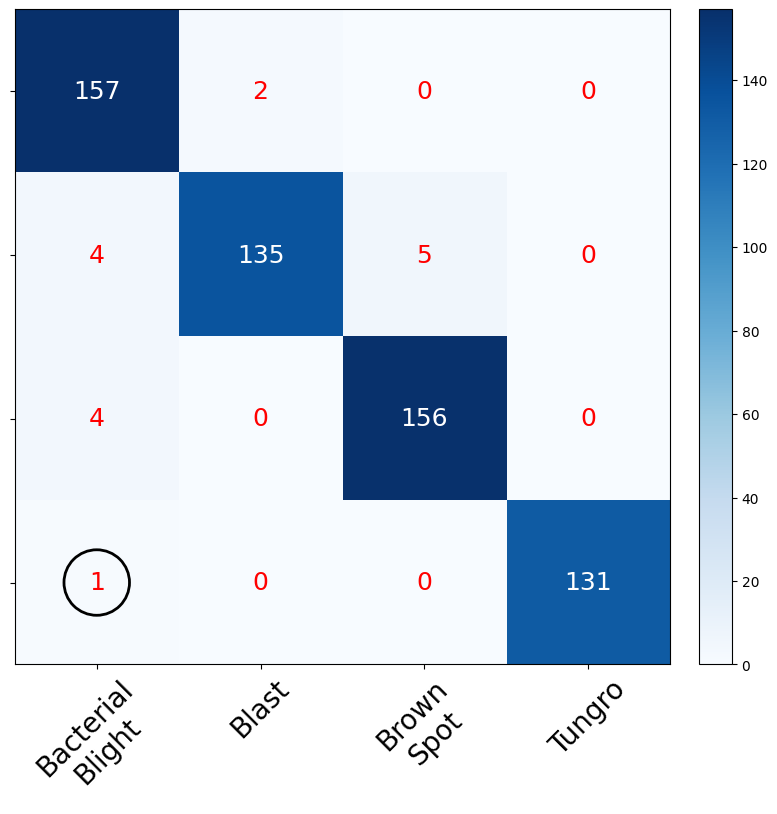

Classification Report for Distiller Model:
                   precision    recall  f1-score   support

Bacterial
Blight       0.95      0.99      0.97       159
           Blast       0.99      0.94      0.96       144
      Brown
Spot       0.97      0.97      0.97       160
          Tungro       1.00      0.99      1.00       132

        accuracy                           0.97       595
       macro avg       0.98      0.97      0.97       595
    weighted avg       0.97      0.97      0.97       595



In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load the saved distiller model
distiller_model = tf.keras.models.load_model(r'saved_models\best_distilled_student_T10_seed1918.h5')

# Compile the model
distiller_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Evaluate the model on the test set
test_set.reset()
distiller_model.evaluate(test_set)

# Extract test data and labels
def extract_test_data(generator):
    generator.reset()
    data_list, labels_list = [], []
    for _ in range(len(generator)):
        data, labels = generator.next()
        data_list.append(data)
        labels_list.append(labels)
    x_test = np.vstack(data_list)
    y_test = np.vstack(labels_list)
    return x_test, y_test

x_test, y_test = extract_test_data(test_set)

# Generate predictions
y_pred_probs = distiller_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)
classes = {0: "Bacterial\nBlight", 1: "Blast", 2: "Brown\nSpot", 3: "Tungro"}

# Plot the confusion matrix
plt.figure(figsize=(8, 8))
im = plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, fraction=0.046, pad=0.04)  # Show blue colormap

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, [classes[i] for i in range(len(classes))], rotation=45, fontsize=20)
plt.yticks(tick_marks, [''] * len(classes))  # Remove y-axis labels

# Add text annotations
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center',
                 fontsize=18,
                 color='red' if i != j else 'white')
        
# Add a circle in the 2nd row, 3rd column (index (1, 2))
circle = plt.Circle((0, 3), 0.2, color='black', fill=False, linewidth=2)  # 2nd row, 3rd column
plt.gca().add_patch(circle)
plt.tight_layout()
plt.show()

# Print classification report
report = classification_report(y_true, y_pred, target_names=[classes[i] for i in range(len(classes))])
print("Classification Report for Distiller Model:\n", report)


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
import os
import json

# ============================
# Configuration
# ============================
Input_Image = 256
batch_size = 32
model_path = 'VGG16_To_Student\VGG16_Teacher.h5'
output_dir = 'evaluation_results'
os.makedirs(output_dir, exist_ok=True)

# ============================
# Load Model and Data
# ============================
print("Loading model...")
loaded_model = tf.keras.models.load_model(model_path)
loaded_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Loading test data...")
test_data = ImageDataGenerator(rescale=1./255)
test_set = test_data.flow_from_directory(
    "test",
    target_size=(Input_Image, Input_Image),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

class_names = list(test_set.class_indices.keys())
num_classes = len(class_names)

# ============================
# Evaluate and Get Predictions
# ============================
print("\nEvaluating model...")
test_loss, test_accuracy = loaded_model.evaluate(test_set, verbose=1)
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

print("\nGenerating predictions...")
test_set.reset()
y_true = []
y_pred = []
y_pred_probs = []
all_images = []

for batch_idx in range(len(test_set)):
    x_batch, y_batch = test_set.next()
    predictions = loaded_model.predict(x_batch, verbose=0)
    
    all_images.extend(x_batch)
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))
    y_pred_probs.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_probs = np.array(y_pred_probs)
all_images = np.array(all_images)

# ============================
# Confusion Matrix
# ============================
print("\nGenerating confusion matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.savefig(f'{output_dir}/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================
# Classification Report
# ============================
print("\nClassification Report:")
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

with open(f'{output_dir}/classification_report.txt', 'w') as f:
    f.write(report)

# ============================
# Grad-CAM Implementation
# ============================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generate Grad-CAM heatmap for a given image
    """
    # Create a model that maps the input image to the activations of the last conv layer
    # as well as the output predictions
    grad_model = Model(
        inputs=[model.input],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    # Compute the gradient of the predicted class with respect to the activations
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    
    # Gradient of the output neuron with regard to the output feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)
    
    # Vector of mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Multiply each channel in the feature map array by importance
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalize the heatmap
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def apply_gradcam_overlay(img, heatmap, alpha=0.4):
    """
    Apply Grad-CAM heatmap as an overlay on the original image
    """
    # Resize heatmap to match image size
    heatmap = np.uint8(255 * heatmap)
    
    # Use jet colormap to colorize heatmap
    jet = plt.cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    
    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)
    
    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img * 255
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)
    
    return superimposed_img

# Find the last convolutional layer
last_conv_layer_name = None
for layer in reversed(loaded_model.layers):
    if 'conv' in layer.name.lower():
        last_conv_layer_name = layer.name
        break

if last_conv_layer_name is None:
    print("Warning: No convolutional layer found. Grad-CAM requires a CNN architecture.")
else:
    print(f"\nUsing last conv layer: {last_conv_layer_name}")

# ============================
# Generate Grad-CAM for All Misclassified Images
# ============================
print("\nFinding misclassified images...")
misclassified_indices = np.where(y_true != y_pred)[0]
num_misclassified = len(misclassified_indices)

print(f"Found {num_misclassified} misclassified images ({num_misclassified/len(y_true)*100:.2f}%)")

if num_misclassified > 0 and last_conv_layer_name is not None:
    print(f"\nGenerating Grad-CAM visualizations for all {num_misclassified} misclassified images...")
    
    # Create directory for misclassified images
    misclassified_dir = f'{output_dir}/misclassified_gradcam'
    os.makedirs(misclassified_dir, exist_ok=True)
    
    # Save metadata
    misclassified_data = []
    
    # Generate Grad-CAM for each misclassified image
    for idx, mis_idx in enumerate(misclassified_indices):
        if (idx + 1) % 10 == 0:
            print(f"  Processing {idx + 1}/{num_misclassified}...")
        
        img = all_images[mis_idx]
        true_label = class_names[y_true[mis_idx]]
        pred_label = class_names[y_pred[mis_idx]]
        confidence = y_pred_probs[mis_idx][y_pred[mis_idx]] * 100
        
        # Generate Grad-CAM heatmap
        img_array = np.expand_dims(img, axis=0)
        heatmap = make_gradcam_heatmap(img_array, loaded_model, last_conv_layer_name)
        
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Original image
        axes[0].imshow(img)
        axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
        axes[0].axis('off')
        
        # Grad-CAM heatmap
        axes[1].imshow(img)
        axes[1].imshow(heatmap, cmap='jet', alpha=0.5)
        axes[1].set_title('Grad-CAM Heatmap', fontsize=12, fontweight='bold')
        axes[1].axis('off')
        
        # Superimposed
        superimposed = apply_gradcam_overlay(img, heatmap)
        axes[2].imshow(superimposed)
        axes[2].set_title('Grad-CAM Overlay', fontsize=12, fontweight='bold')
        axes[2].axis('off')
        
        # Overall title
        fig.suptitle(f'True: {true_label} | Predicted: {pred_label} | Confidence: {confidence:.1f}%',
                     fontsize=14, fontweight='bold', color='red')
        
        plt.tight_layout()
        
        # Save figure
        save_path = f'{misclassified_dir}/misclassified_{idx+1:04d}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
        
        # Store metadata
        misclassified_data.append({
            'index': int(mis_idx),
            'true_label': true_label,
            'predicted_label': pred_label,
            'confidence': float(confidence),
            'image_file': save_path
        })
    
    # Save metadata to JSON
    with open(f'{misclassified_dir}/misclassified_metadata.json', 'w') as f:
        json.dump(misclassified_data, f, indent=4)
    
    print(f"\n✓ All Grad-CAM visualizations saved to: {misclassified_dir}/")
    print(f"✓ Metadata saved to: {misclassified_dir}/misclassified_metadata.json")
    
    # Create summary visualization (first 20 misclassified)
    num_to_show = min(20, num_misclassified)
    rows = 4
    cols = 5
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 16))
    axes = axes.flatten()
    
    for i in range(num_to_show):
        mis_idx = misclassified_indices[i]
        img = all_images[mis_idx]
        true_label = class_names[y_true[mis_idx]]
        pred_label = class_names[y_pred[mis_idx]]
        confidence = y_pred_probs[mis_idx][y_pred[mis_idx]] * 100
        
        # Generate and apply Grad-CAM
        img_array = np.expand_dims(img, axis=0)
        heatmap = make_gradcam_heatmap(img_array, loaded_model, last_conv_layer_name)
        
        # Show overlay
        axes[i].imshow(img)
        axes[i].imshow(heatmap, cmap='jet', alpha=0.5)
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\n{confidence:.1f}%',
                         fontsize=10, color='red', fontweight='bold')
        axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(num_to_show, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Grad-CAM Analysis of Misclassified Images (Sample)', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/misclassified_summary.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Summary visualization saved to: {output_dir}/misclassified_summary.png")

print("\n" + "="*80)
print("EVALUATION COMPLETE!")
print("="*80)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Misclassified: {num_misclassified}/{len(y_true)} ({num_misclassified/len(y_true)*100:.2f}%)")
print(f"Results saved in: {output_dir}/")
print("="*80)